# Consumer Shopping Behaviour Analysis

In [468]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as pex

sns.set_style("whitegrid")
chart_agg = []

## Data loading and inspecting

In [469]:
df = pd.read_csv("customer_shopping_behavior.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [470]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [471]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [472]:
df.duplicated().sum()

np.int64(0)

## Data cleaning and formating

In [473]:
df.isna().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [474]:
df[df.isna().any(axis=1)].head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
38,39,29,Male,Dress,Clothing,37,Florida,M,Red,Winter,NaN,Yes,2-Day Shipping,Yes,Yes,44,Venmo,Every 3 Months
50,51,49,Male,Blouse,Clothing,28,Maryland,M,Red,Spring,NaN,Yes,Store Pickup,Yes,Yes,39,Debit Card,Bi-Weekly
80,81,19,Male,Sandals,Footwear,72,New York,XL,Blue,Summer,NaN,Yes,Store Pickup,Yes,Yes,24,Credit Card,Every 3 Months
96,97,32,Male,Gloves,Accessories,73,Delaware,S,Gold,Spring,NaN,Yes,Express,Yes,Yes,43,Venmo,Every 3 Months
262,263,37,Male,Pants,Clothing,40,Hawaii,M,Teal,Summer,NaN,Yes,Next Day Air,Yes,Yes,6,Debit Card,Annually


In [475]:
df["Review Rating"] = df.groupby(["Category"])["Review Rating"].transform(lambda x : x.fillna(x.median()))

In [476]:
df.isna().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

## Data Visualization

## Category Analysis

In [477]:
df.sample()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
253,254,52,Male,Boots,Footwear,73,Oklahoma,L,Cyan,Winter,4.9,Yes,2-Day Shipping,Yes,Yes,15,Bank Transfer,Bi-Weekly


In [478]:
# category Count - pd and charts
cat_count = df["Category"].value_counts(sort = False).reset_index()
cat_count

,Category,count
0,Clothing,1737
1,Footwear,599
2,Outerwear,324
3,Accessories,1240


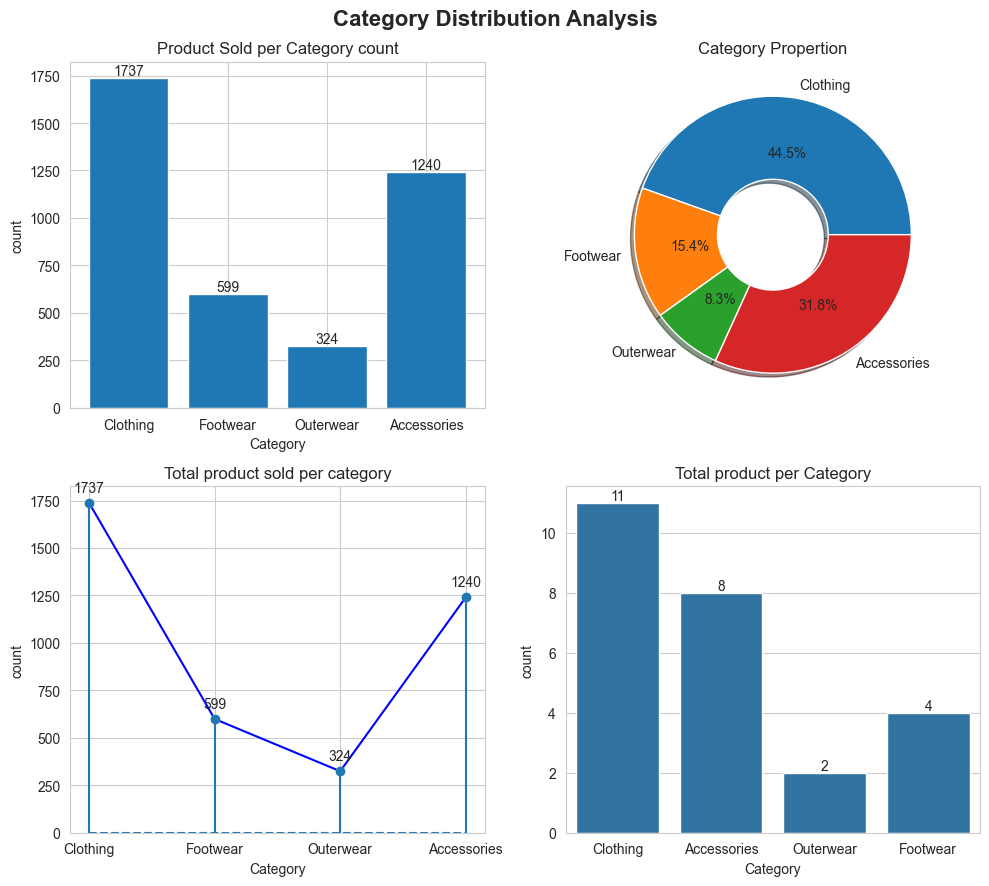

In [479]:
fig, ax = plt.subplots(ncols = 2, nrows= 2, figsize  = (10, 9))

ax[0, 0].bar(cat_count["Category"], cat_count["count"])
ax[0, 0].set(title = "Product Sold per Category count", xlabel = "Category", ylabel = "count")
ax[0, 0].bar_label(ax[0,0].containers[0])

ax[0, 1].pie(cat_count["count"], labels= cat_count["Category"], wedgeprops = {"width" : 0.6}, autopct = "%0.01f%%", shadow = True)
ax[0, 1].set(title = "Category Propertion")


sns.lineplot(ax =  ax[1, 0],  data = cat_count, x = "Category", y = "count",  marker='o', color = "blue")
ax[1, 0].stem(cat_count["Category"], cat_count["count"], bottom = 0, basefmt = "--")
ax[1, 0].set(title = "Total product sold per category", xlabel = "Category", ylabel = "count")
for i, j in zip(cat_count["Category"], cat_count["count"]):
    ax[1, 0].annotate(j, (i, j), textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=10)
ax[1, 0].set_ylim(bottom=0)
# plt.annotate()
product_count = df[["Category", "Item Purchased"]].value_counts().reset_index()

sns.countplot(ax =  ax[1, 1],  data = product_count,  x = "Category", orient= "v")
ax[1, 1].bar_label(ax[1,1].containers[0])
ax[1, 1].set(title = "Total product per Category")

fig.suptitle("Category Distribution Analysis", fontsize = 16, fontweight = "bold")
plt.tight_layout()
chart_agg.append(fig)
plt.show()

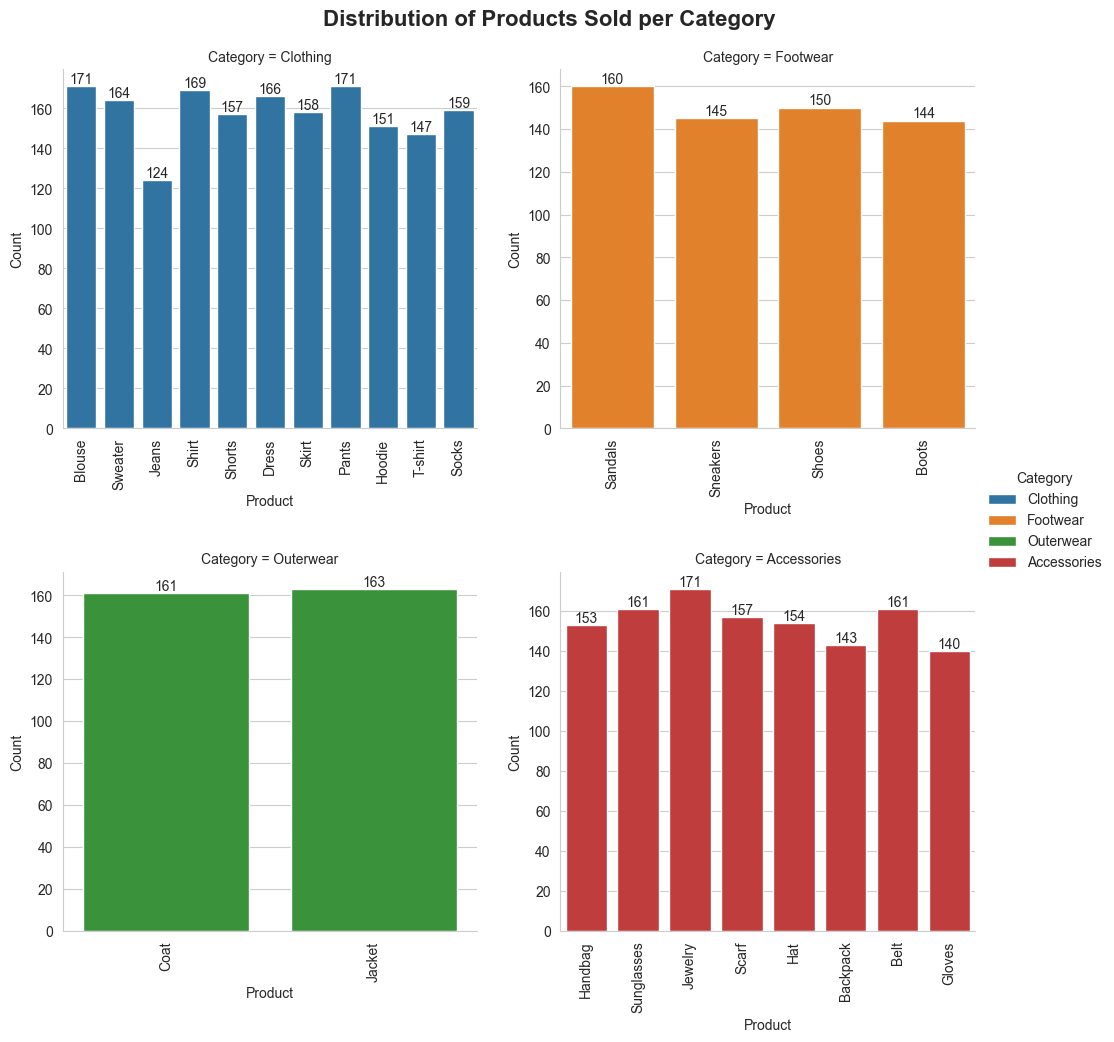

In [480]:
# count of item purchase per category 
g = sns.catplot(data= df, x = "Item Purchased", hue= "Category", col="Category", kind= "count", col_wrap= 2, sharex=False, sharey= False)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)
    ax.set_xlabel("Product")
    ax.set_ylabel("Count")
g.set_xticklabels(rotation = 90)
plt.suptitle("Distribution of Products Sold per Category", fontsize = 16, fontweight = "bold")
g.fig.subplots_adjust(hspace=0.4, wspace=0.2, top = 0.92)
chart_agg.append(plt.gcf())
plt.show()

In [481]:
total_sales_perCate = df.groupby(["Category"])["Purchase Amount (USD)"].agg([("Total Sales", "sum"), ("Avg. Sales", "mean")]).reset_index()
total_sales_perCate

,Category,Total Sales,Avg. Sales
0,Accessories,74200,59.838710
1,Clothing,104264,60.025331
2,Footwear,36093,60.255426
3,Outerwear,18524,57.172840


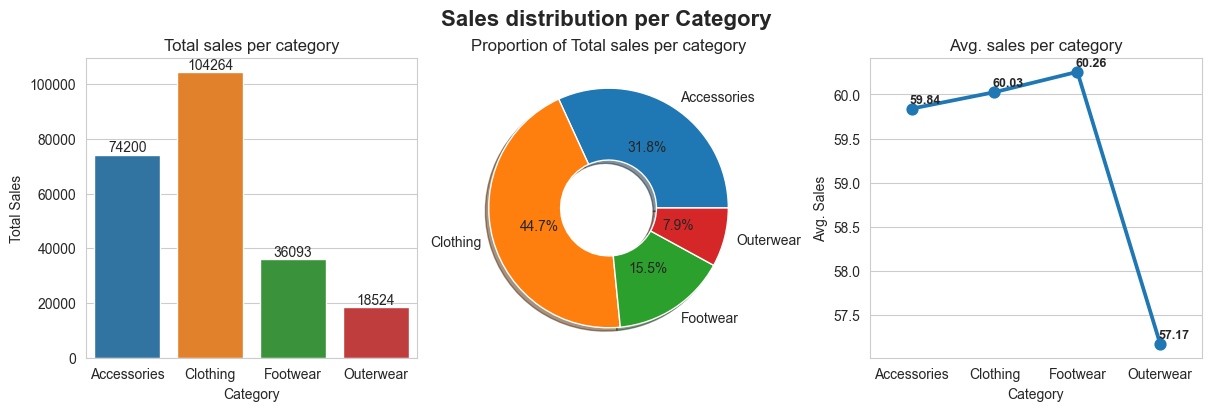

In [482]:
fig, ax = plt.subplots(ncols=3, figsize = (12, 4), layout = "constrained")

sns.barplot(ax = ax[0], data = total_sales_perCate, x = total_sales_perCate["Category"], y = total_sales_perCate["Total Sales"], hue = "Category")
ax[0].set_title("Total sales per category")
for i in ax[0].containers:
    ax[0].bar_label(i)
# ax[0].set_title("Total sales per category")

ax[1].pie(x = total_sales_perCate["Total Sales"], labels = total_sales_perCate["Category"], wedgeprops = {"width" : 0.6}, autopct = "%0.01f%%", shadow = True)
ax[1].set_title("Proportion of Total sales per category")

sns.pointplot(ax = ax[2], data = total_sales_perCate, x = total_sales_perCate["Category"], y = total_sales_perCate["Avg. Sales"])
for i,j in zip(total_sales_perCate["Category"], total_sales_perCate["Avg. Sales"]):
    ax[2].annotate(f"{j:.02f}", (i, j), textcoords='offset points', xytext=(10, 4),
                     ha='center', fontsize=9, fontweight='bold')
ax[2].set_title("Avg. sales per category")

# fig.subplots_adjust(top = 0.9)
fig.suptitle("Sales distribution per Category", fontsize = 16, fontweight = 'bold')
chart_agg.append(fig)
plt.show()

In [483]:
total_sales_perCate_item = df.groupby(["Category", "Item Purchased"])["Purchase Amount (USD)"].agg([("Total Sales", "sum")]).reset_index()
total_sales_perCate_item

,Category,Item Purchased,Total Sales
0,Accessories,Backpack,8636
1,Accessories,Belt,9635
2,Accessories,Gloves,8477
3,Accessories,Handbag,8857
4,Accessories,Hat,9375
5,Accessories,Jewelry,10010
6,Accessories,Scarf,9561
7,Accessories,Sunglasses,9649
8,Clothing,Blouse,10410
9,Clothing,Dress,10320


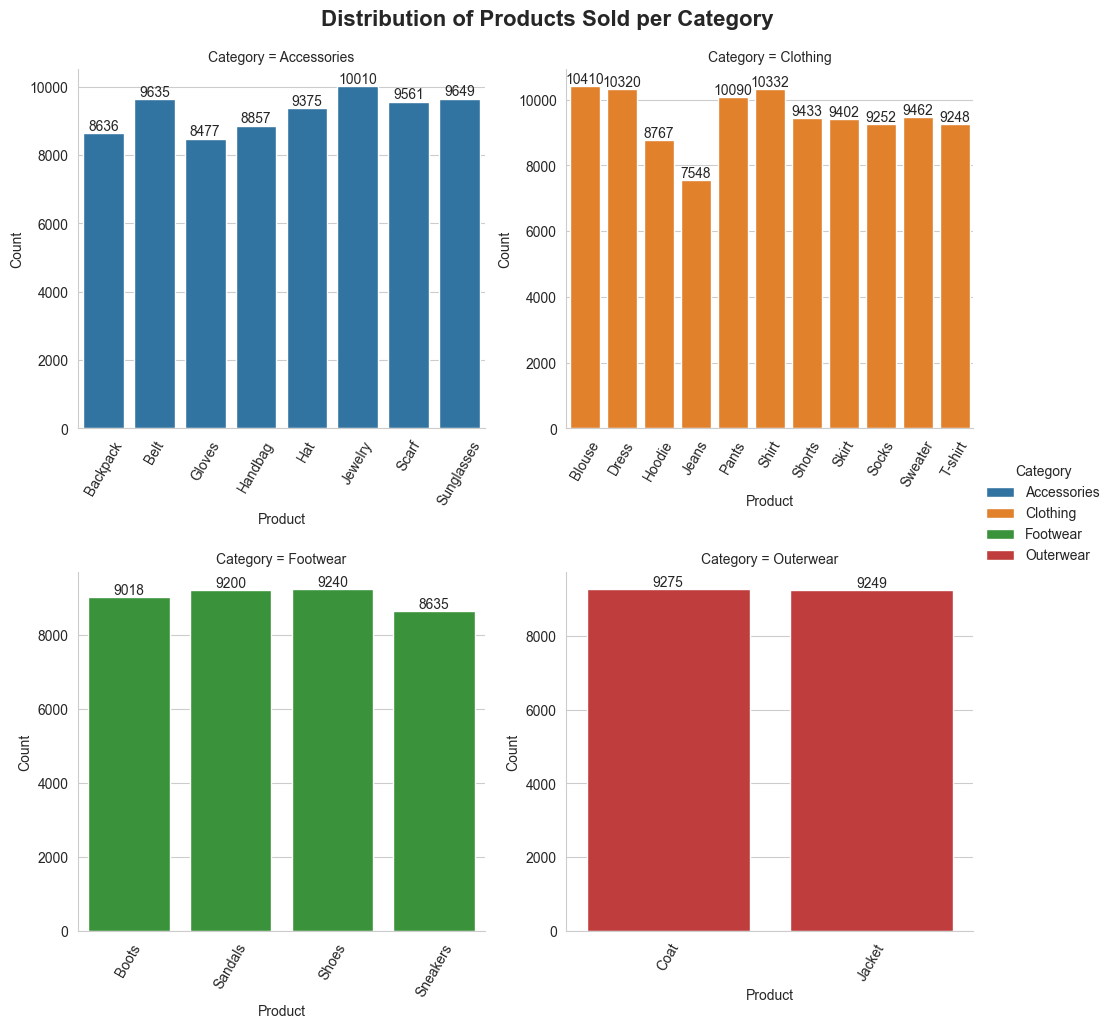

In [484]:
# count of item purchase per category 
g = sns.catplot(data= total_sales_perCate_item, x = "Item Purchased", y = "Total Sales", hue= "Category", col="Category", kind= "bar", col_wrap= 2, sharex=False, sharey= False)
for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container)
    ax.set_xlabel("Product")
    ax.set_ylabel("Count")
g.set_xticklabels(rotation = 60)
plt.suptitle("Distribution of Products Sold per Category", fontsize = 16, fontweight = "bold")
g.fig.subplots_adjust(hspace=0.4, wspace=0.2, top = 0.92)
chart_agg.append(plt.gcf())
plt.show()

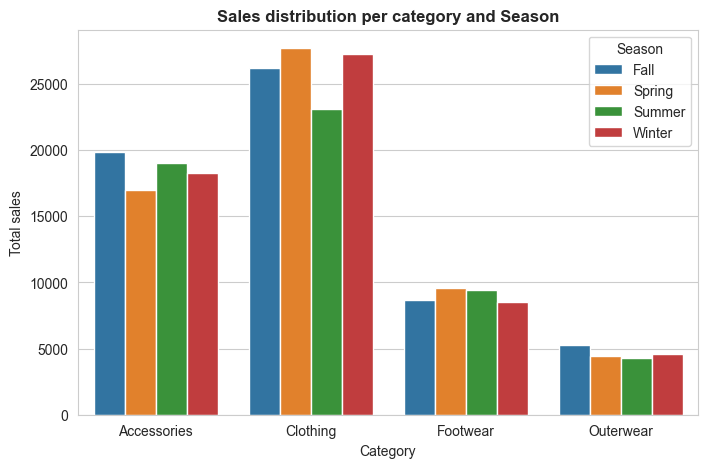

In [485]:
category_season_sales = df.groupby(['Category', 'Season'])['Purchase Amount (USD)'].agg([("Total sales", "sum")]).reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data = category_season_sales, x = "Category", y = "Total sales", hue = "Season")
plt.title("Sales distribution per category and Season", fontsize = 12, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()

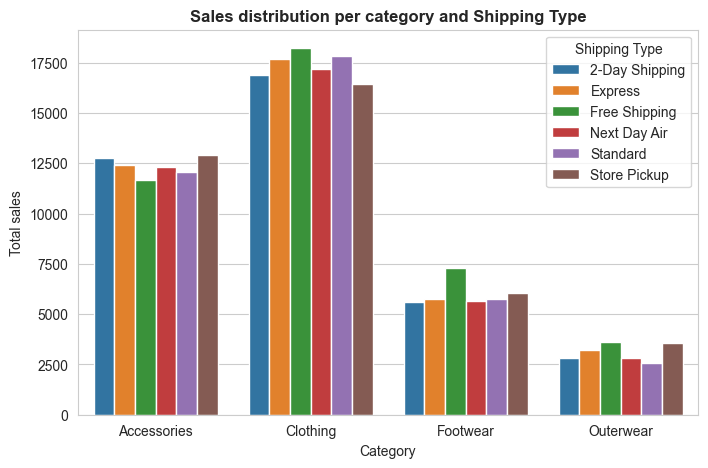

In [486]:
category_season_sales = df.groupby(['Category', 'Shipping Type'])['Purchase Amount (USD)'].agg([("Total sales", "sum")]).reset_index()
# print(category_season_sales)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data = category_season_sales, x = "Category", y = "Total sales", hue = "Shipping Type")
# for container in ax.containers:
#     ax.bar_label(container, rotation = 90)
plt.title("Sales distribution per category and Shipping Type", fontsize = 12, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()

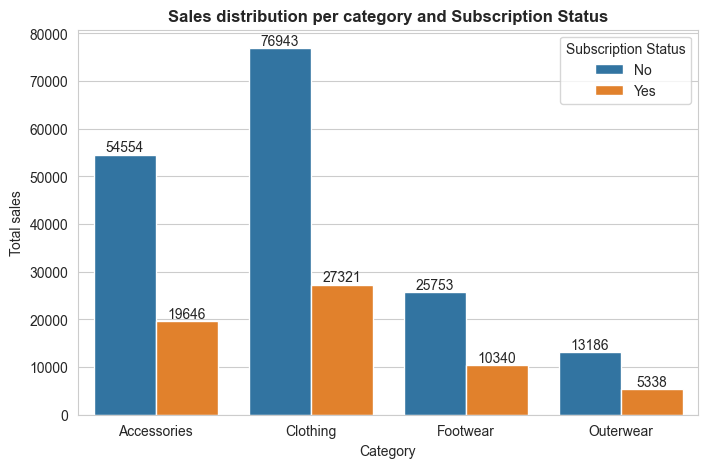

In [487]:
category_season_sales = df.groupby(['Category', 'Subscription Status'])['Purchase Amount (USD)'].agg([("Total sales", "sum")]).reset_index()
# print(category_season_sales)
plt.figure(figsize=(8, 5))
ax =sns.barplot(data = category_season_sales, x = "Category", y = "Total sales", hue = "Subscription Status")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Sales distribution per category and Subscription Status", fontsize = 12, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()

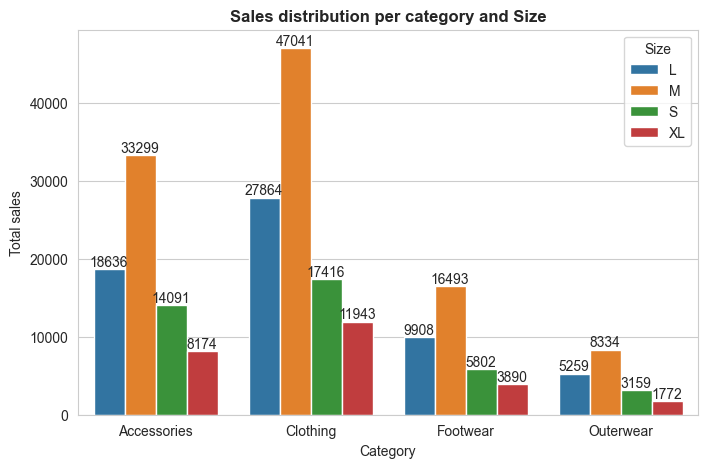

In [488]:
category_season_sales = df.groupby(['Category', 'Size'])['Purchase Amount (USD)'].agg([("Total sales", "sum")]).reset_index()
# print(category_season_sales)
plt.figure(figsize=(8, 5))
ax = sns.barplot(data = category_season_sales, x = "Category", y = "Total sales", hue = "Size")
for container in ax.containers:
    ax.bar_label(container)
plt.title("Sales distribution per category and Size", fontsize = 12, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_7788\3812972901.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top4_country = category_season_sales.groupby(["Category"], group_keys= False).apply(lambda x : x.nlargest(4, "Total sales")).reset_index()


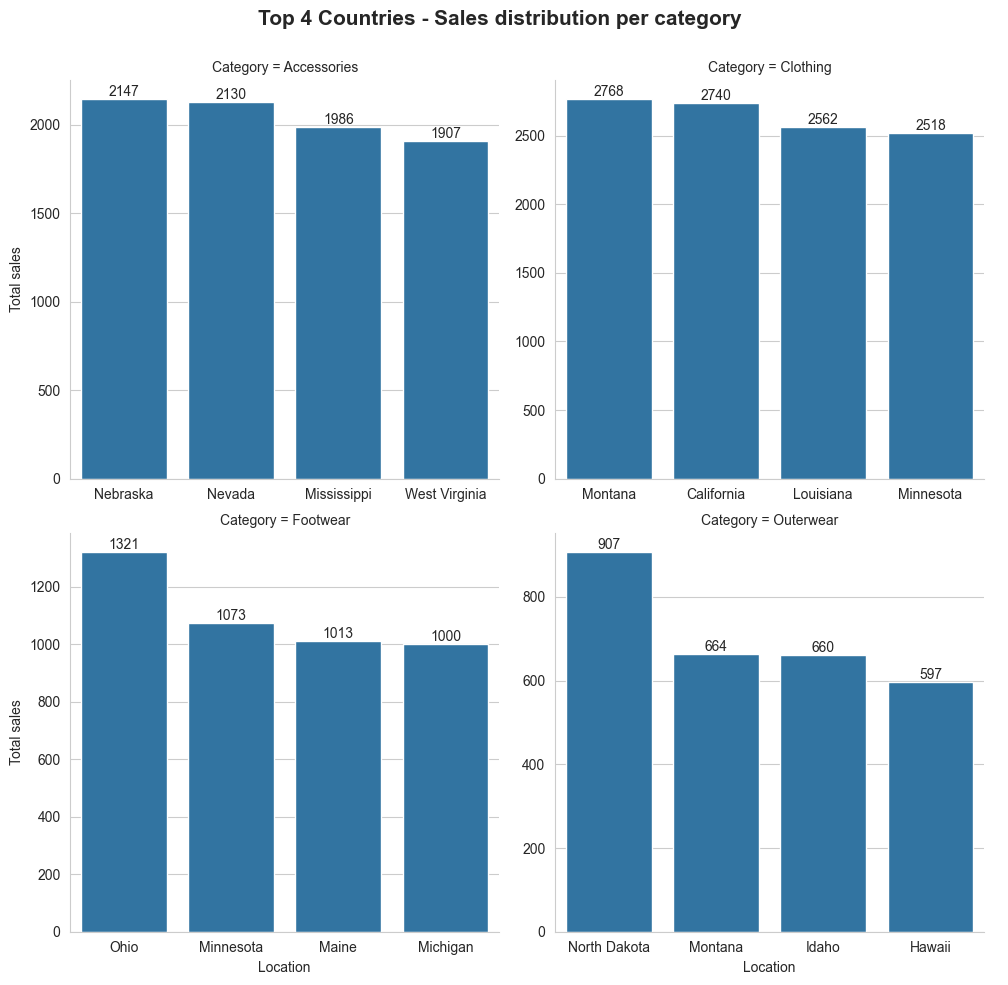

In [489]:
category_season_sales = df.groupby(['Category', 'Location'])['Purchase Amount (USD)'].agg([("Total sales", "sum")]).reset_index()
top4_country = category_season_sales.groupby(["Category"], group_keys= False).apply(lambda x : x.nlargest(4, "Total sales")).reset_index()
# print(top4_country)
g = sns.catplot(data = top4_country, x = "Location", y = "Total sales", kind = "bar", col = "Category", sharex= False, sharey= False, col_wrap = 2)
for i in g.axes.flat:
    i.bar_label(i.containers[0])
plt.subplots_adjust(top = 0.91)
plt.suptitle("Top 4 Countries - Sales distribution per category", fontsize = 15, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()

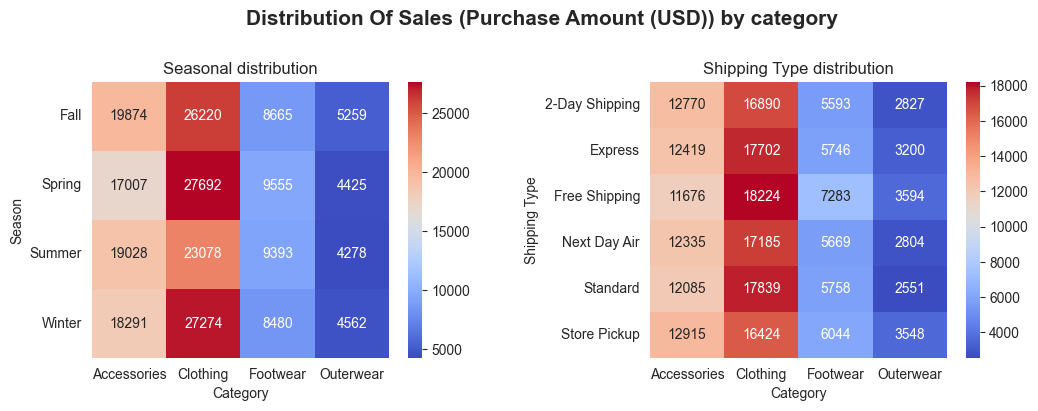

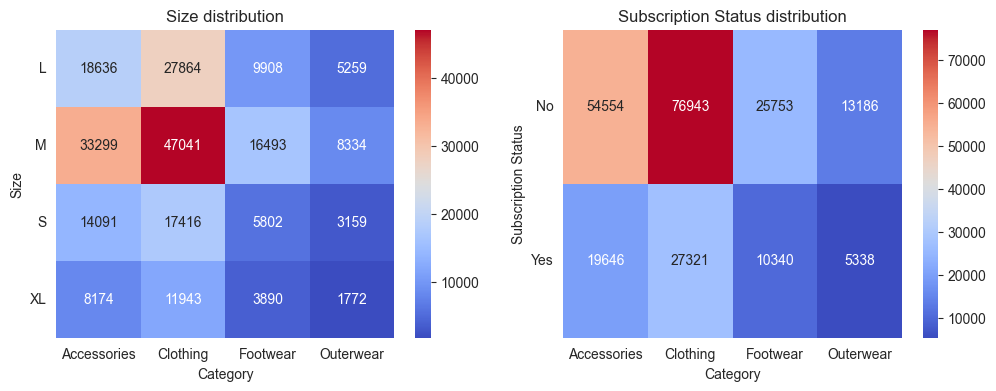

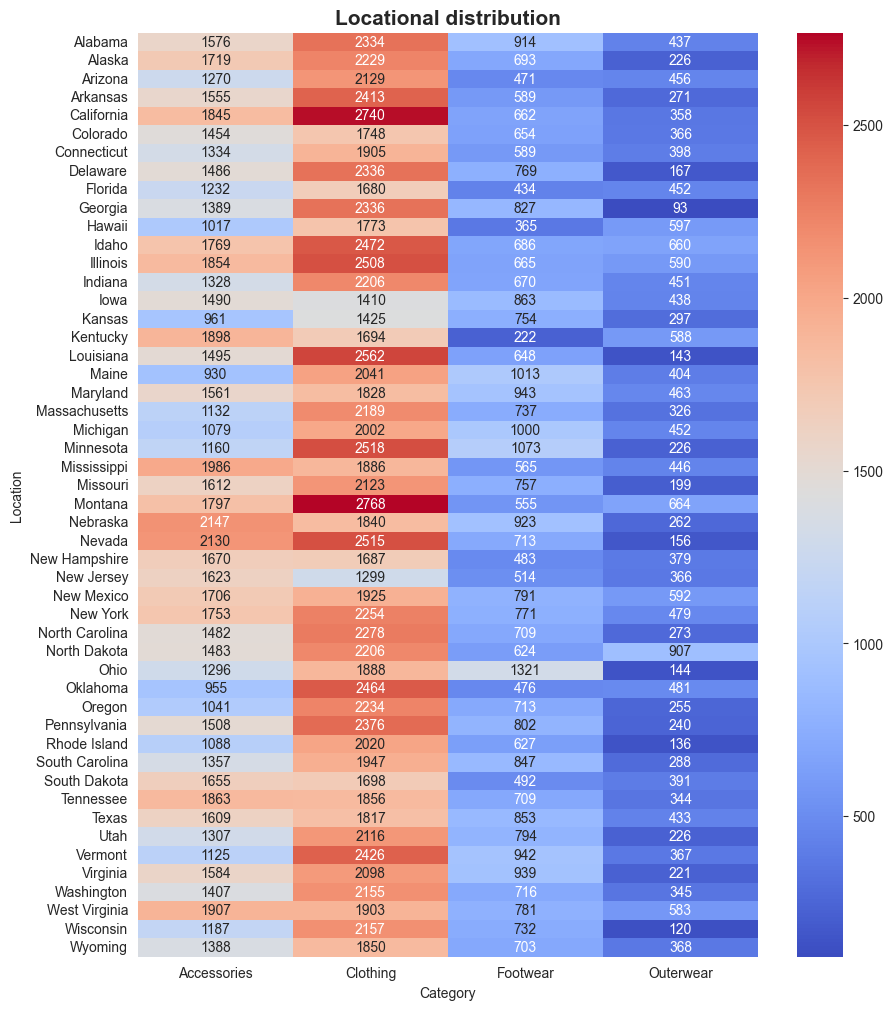

In [490]:
# sns.violinplot(data = df, x = "Category", hue  = "Season")
fig, ax = plt.subplots(ncols = 2, figsize=(12, 4))


pivot = df.pivot_table(
    index='Season',
    columns='Category',
    values='Purchase Amount (USD)',
    aggfunc='sum'
)

sns.heatmap(ax = ax[0], data = pivot, annot=True, fmt=".0f", cmap="coolwarm")
ax[0].set_title("Seasonal distribution")
ax[0].tick_params(axis = "y", rotation = 0)

pivot = df.pivot_table(
    index='Shipping Type',
    columns='Category',
    values='Purchase Amount (USD)',
    aggfunc='sum'
)

sns.heatmap(ax = ax[1], data = pivot, annot=True, fmt=".0f", cmap="coolwarm")
ax[1].set_title("Shipping Type distribution")
chart_agg.append(fig)

fig1, ax = plt.subplots(ncols = 2, figsize=(12, 4))

size_purchase = df.pivot_table(index="Size", columns = "Category", values = "Purchase Amount (USD)", aggfunc= "sum")
# size_purchase

sns.heatmap(ax = ax[0], data = size_purchase, annot=True, fmt=".0f", cmap="coolwarm")
ax[0].set_title("Size distribution")
ax[0].tick_params(axis = "y", rotation = 0)

pivot = df.pivot_table(
    index='Subscription Status',
    columns='Category',
    values='Purchase Amount (USD)',
    aggfunc='sum'
)
sns.heatmap(ax = ax[1], data = pivot, annot=True, fmt=".0f", cmap="coolwarm")
ax[1].set_title("Subscription Status distribution")
ax[1].tick_params(axis = "y", rotation = 0)
chart_agg.append(fig1)

pivot = df.pivot_table(
    index='Location',
    columns='Category',
    values='Purchase Amount (USD)',
    aggfunc='sum'
)

plt.figure(figsize=(10, 12))
sns.heatmap(data = pivot, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Locational distribution", fontsize = 15, fontweight = 'bold')

fig.subplots_adjust(wspace= 0.5, hspace= 0.2, top= 0.8)
# fig1.subplots_adjust(wspace= 0.5, hspace= 0.2, top= 0.8)
fig.suptitle("Distribution Of Sales (Purchase Amount (USD)) by category", fontsize = 15, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()

,mean,max,min,25 Percentile,50 Percentile,70 Percentile
Category,,,,,,
Accessories,59.838710,100,20,39.75,60.0,80.0
Clothing,60.025331,100,20,38.00,60.0,81.0
Footwear,60.255426,100,20,39.00,60.0,81.0
Outerwear,57.172840,100,20,34.00,54.5,80.0


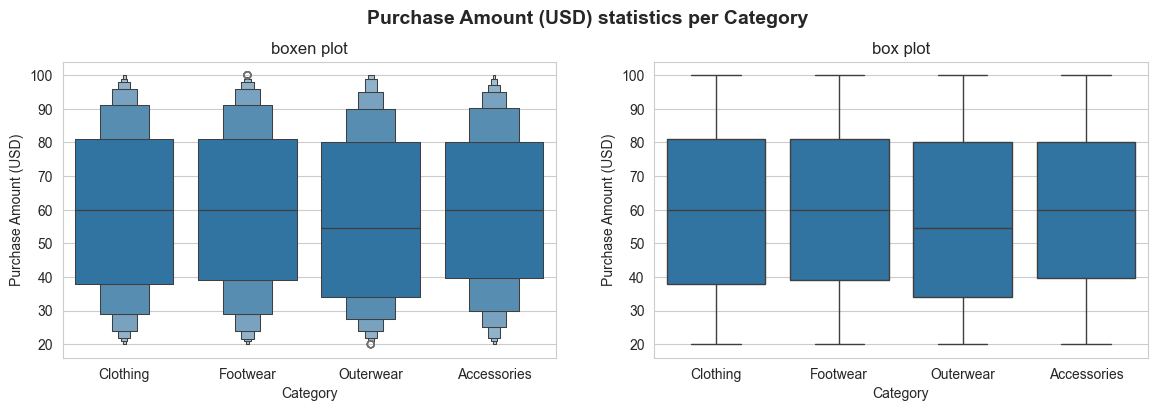

In [491]:
# purchase amount (USD) distribution by Category
stat_pur = df.groupby(["Category"])["Purchase Amount (USD)"].aggregate(["mean", "max", "min", ("25 Percentile", lambda x : x.quantile(0.25)), ("50 Percentile", lambda x : x.quantile(0.50)), ("70 Percentile", lambda x : x.quantile(0.75))])
fig, ax = plt.subplots(ncols= 2, figsize = (14, 4))
sns.boxenplot(ax = ax[0], data = df, x = "Category", y = "Purchase Amount (USD)")
ax[0].set_title("boxen plot")

sns.boxplot(ax = ax[1], data = df, x = "Category", y = "Purchase Amount (USD)")
ax[1].set_title("box plot")
display(stat_pur)
plt.suptitle("Purchase Amount (USD) statistics per Category", fontsize = 14, fontweight = 'bold')
plt.subplots_adjust(hspace= 0.4, top = 0.85)
chart_agg.append(fig)
plt.show()

## Item wise Analysis

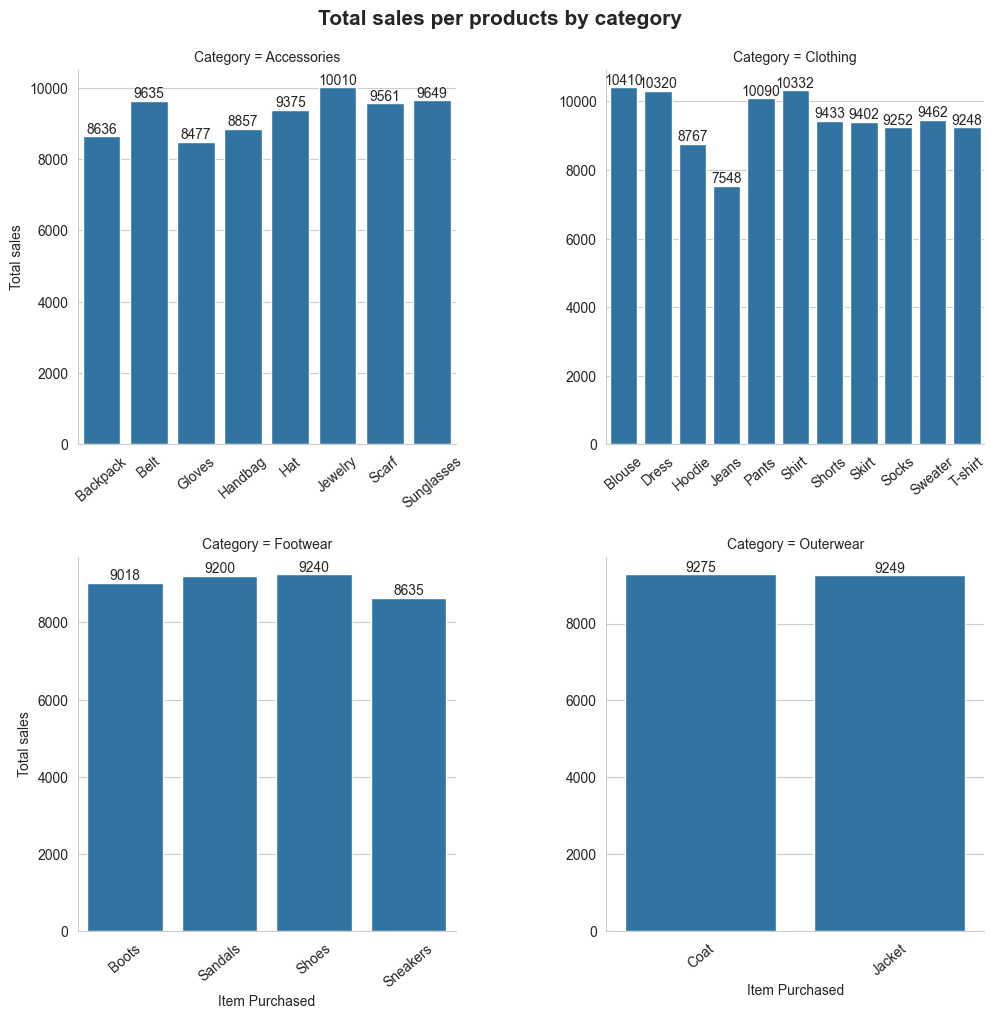

In [492]:
cate_df = df.groupby(["Category", "Item Purchased"])["Purchase Amount (USD)"].agg([("Total sales", "sum")])
# plt.figure(figsize= (10, 5))
g = sns.catplot(data=cate_df, x = "Item Purchased", y = "Total sales", kind = "bar", col = 'Category', sharex= False, sharey= False, col_wrap= 2)
for i in g.axes.flat:
    i.bar_label(i.containers[0])
    i.tick_params(axis = 'x', rotation = 40)
plt.suptitle("Total sales per products by category", fontsize = 15, fontweight = "bold")
plt.subplots_adjust(hspace= 0.3, wspace= 0.4, top= 0.92)
chart_agg.append(plt.gcf())
plt.show()

In [493]:
cate_df = df.groupby(["Category", "Item Purchased"])["Purchase Amount (USD)"].sum().reset_index()
cat_df = cate_df.groupby("Category", group_keys=False).apply(lambda x: x.nlargest(4, 'Purchase Amount (USD)'))
cat_df

C:\Users\DELL\AppData\Local\Temp\ipykernel_7788\1019425429.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cat_df = cate_df.groupby("Category", group_keys=False).apply(lambda x: x.nlargest(4, 'Purchase Amount (USD)'))


,Category,Item Purchased,Purchase Amount (USD)
5,Accessories,Jewelry,10010
7,Accessories,Sunglasses,9649
1,Accessories,Belt,9635
6,Accessories,Scarf,9561
8,Clothing,Blouse,10410
13,Clothing,Shirt,10332
9,Clothing,Dress,10320
12,Clothing,Pants,10090
21,Footwear,Shoes,9240
20,Footwear,Sandals,9200


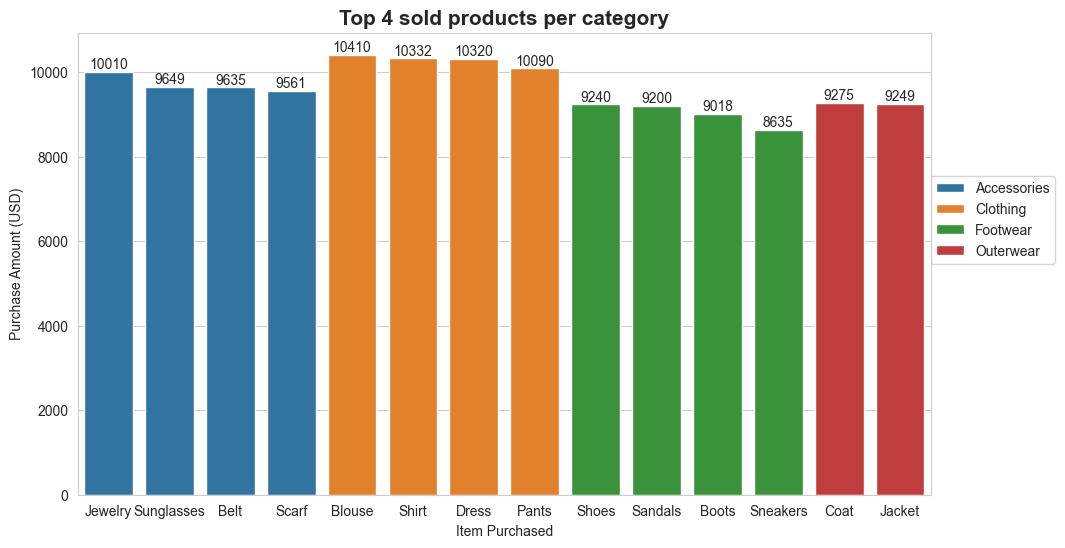

In [494]:
plt.figure(figsize= (11, 6))
ax = sns.barplot(data=cat_df, x = "Item Purchased", y = "Purchase Amount (USD)", hue="Category")
plt.legend(loc=[1, 0.5])
for i in ax.containers:
    ax.bar_label(i)
plt.title("Top 4 sold products per category", fontsize = 15, fontweight = "bold")
chart_agg.append(plt.gcf())
plt.show()

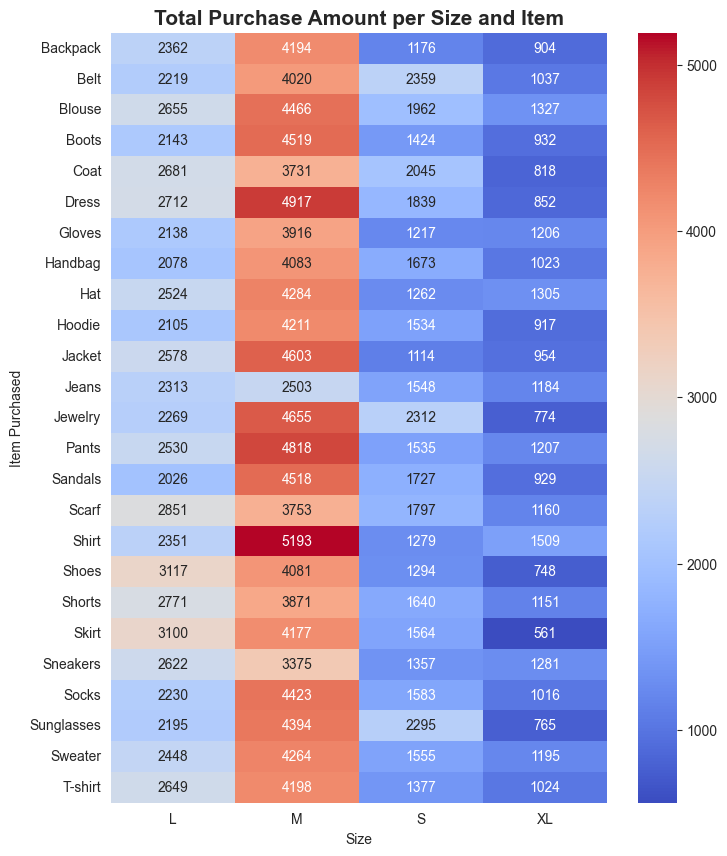

In [495]:
item_size_purchase = df.pivot_table(index="Item Purchased", columns = "Size", values = "Purchase Amount (USD)", aggfunc= "sum")
# size_purchase
plt.figure(figsize=(8, 10))
sns.heatmap(data = item_size_purchase, annot=True, fmt=".0f", cmap="coolwarm")

plt.title("Total Purchase Amount per Size and Item", fontsize = 15, fontweight = "bold")
chart_agg.append(plt.gcf())
plt.show()

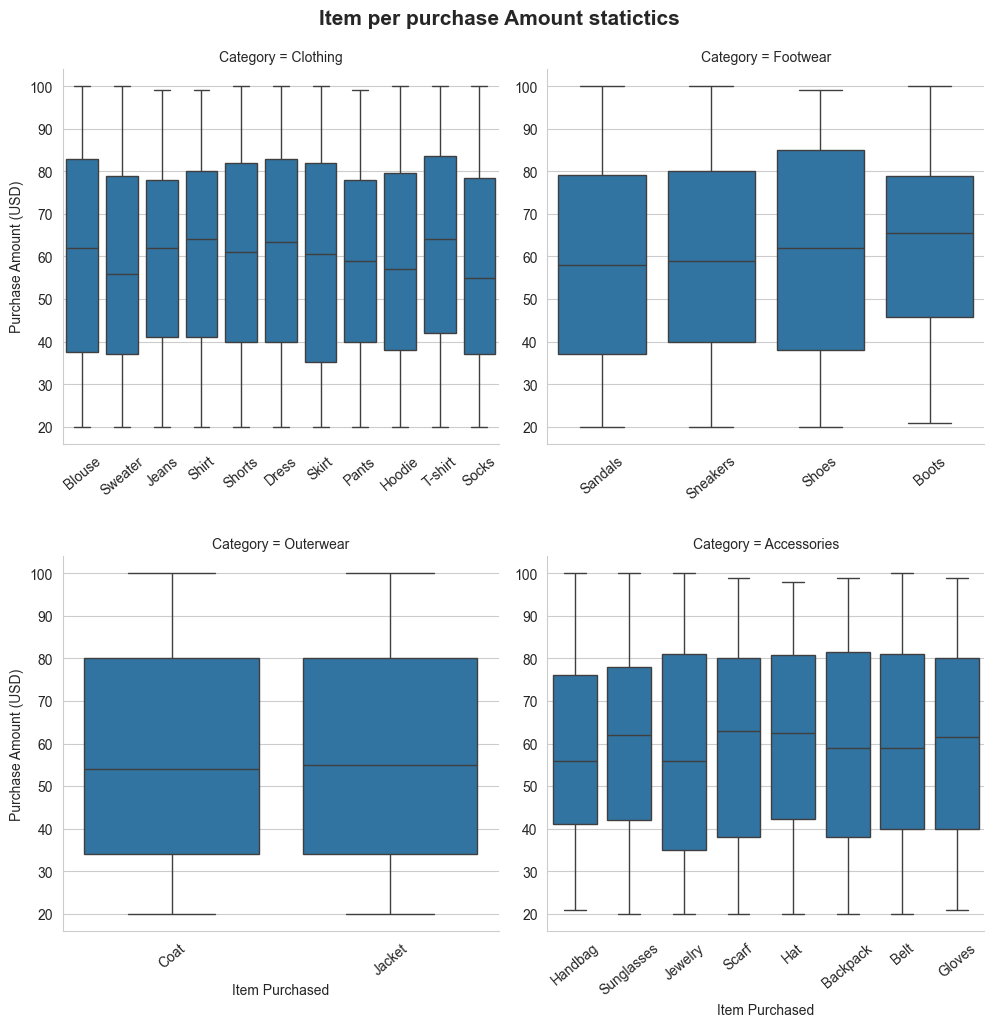

In [496]:
# plt.figure(figsize= (5, 5))
ax = sns.catplot(data = df, x = "Item Purchased", y = "Purchase Amount (USD)", kind = "box", col = "Category", col_wrap= 2, sharex= False, sharey=False)
for i in ax.axes.flat:
    i.tick_params(axis = 'x', rotation = 40)
plt.subplots_adjust(hspace= 0.3, top = 0.92)
plt.suptitle("Item per purchase Amount statictics", fontsize = 15, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()

In [497]:
item_perSeason = df.groupby(["Item Purchased", "Season"])["Purchase Amount (USD)"].agg(["count", "sum"]).reset_index()
item_perSeason

,Item Purchased,Season,count,sum
0,Backpack,Fall,34,2008
1,Backpack,Spring,39,2206
2,Backpack,Summer,45,2780
3,Backpack,Winter,25,1642
4,Belt,Fall,41,2553
...,...,...,...,...
95,Sweater,Winter,42,2365
96,T-shirt,Fall,39,2591
97,T-shirt,Spring,38,2506
98,T-shirt,Summer,30,1640


In [498]:
item_perSize = df.groupby(["Item Purchased", "Size"])["Purchase Amount (USD)"].sum().reset_index()
item_perSize

,Item Purchased,Size,Purchase Amount (USD)
0,Backpack,L,2362
1,Backpack,M,4194
2,Backpack,S,1176
3,Backpack,XL,904
4,Belt,L,2219
...,...,...,...
95,Sweater,XL,1195
96,T-shirt,L,2649
97,T-shirt,M,4198
98,T-shirt,S,1377


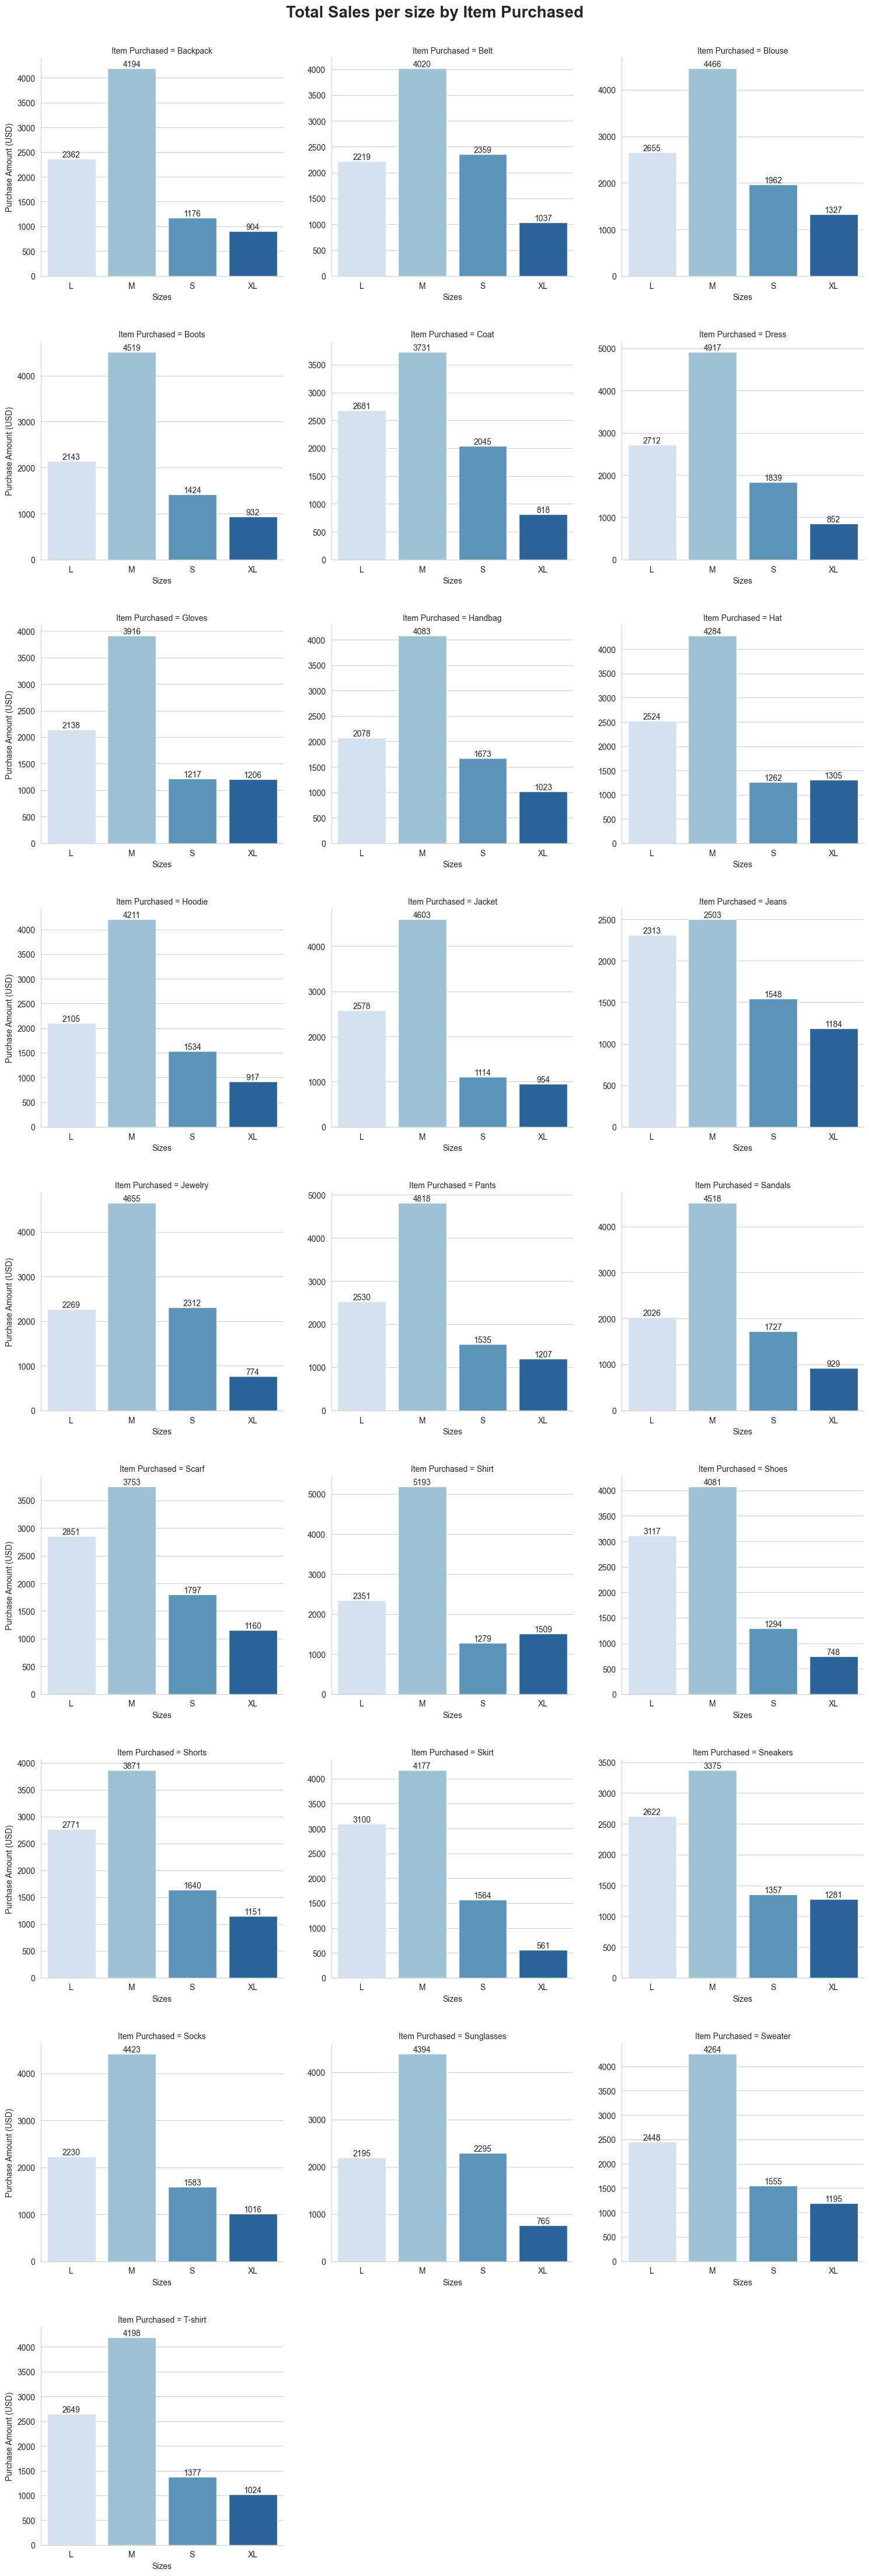

In [499]:
a = sns.catplot(data = item_perSize,  x = "Size", y = "Purchase Amount (USD)", col = "Item Purchased", col_wrap= 3, kind = "bar", sharex =False, hue = "Size", palette = "Blues", legend= False, sharey= False)
for ax in a.axes.flat:
    for i in ax.containers:
        ax.bar_label(i)
    ax.set(xlabel = "Sizes")
a.fig.subplots_adjust(hspace=0.3, wspace=0.2, top = 0.96)
plt.suptitle("Total Sales per size by Item Purchased", fontsize = 20, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()

In [500]:
stat_cat_item = df.groupby(["Category", "Item Purchased"])["Purchase Amount (USD)"].agg(["min", "max", "mean"]).reset_index()
stat_cat_item

,Category,Item Purchased,min,max,mean
0,Accessories,Backpack,20,99,60.391608
1,Accessories,Belt,20,100,59.844720
2,Accessories,Gloves,21,99,60.550000
3,Accessories,Handbag,21,100,57.888889
4,Accessories,Hat,20,98,60.876623
5,Accessories,Jewelry,20,100,58.538012
6,Accessories,Scarf,20,99,60.898089
7,Accessories,Sunglasses,20,100,59.931677
8,Clothing,Blouse,20,100,60.877193
9,Clothing,Dress,20,100,62.168675


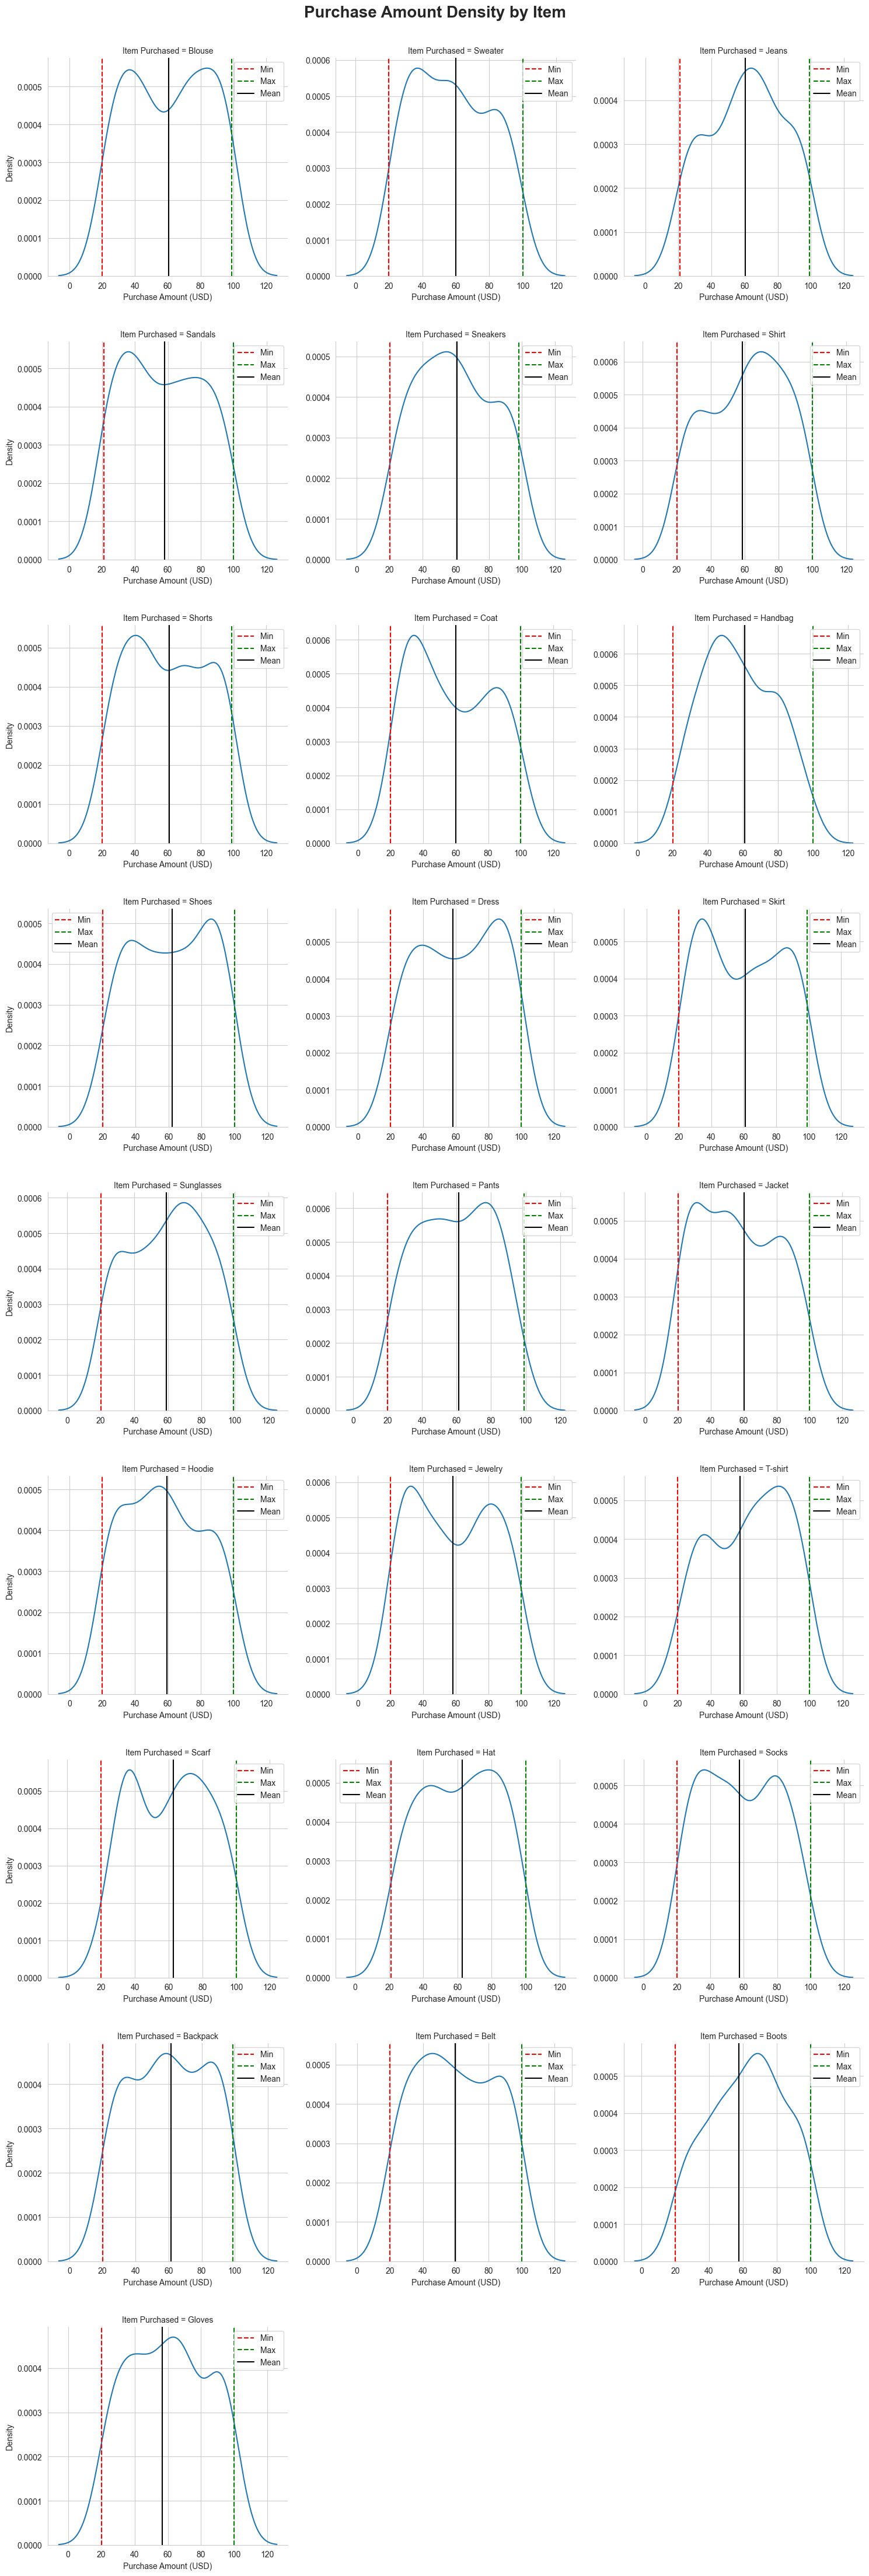

In [501]:
g = sns.displot(
    data=df,
    x="Purchase Amount (USD)",
    kind="kde",
    col="Item Purchased",
    col_wrap=3,
    facet_kws={"sharex": False, "sharey": False}
)

for ax_, (_, row) in zip(g.axes.flat, stat_cat_item.iterrows()):
    # print(row)
    ax_.axvline(row["min"], color="red", linestyle="--", label="Min")
    ax_.axvline(row["max"], color="green", linestyle="--", label="Max")
    ax_.axvline(row["mean"], color="black", linestyle="-", label="Mean")
    ax_.legend()
    ax_.set_xlabel("Purchase Amount (USD)")
    
g.fig.subplots_adjust(hspace=0.3, wspace=0.2, top = 0.96)
plt.suptitle("Purchase Amount Density by Item", fontsize = 20, fontweight = 'bold')
# sns.histplot()
chart_agg.append(plt.gcf())
plt.show()

## Rating Review analysis

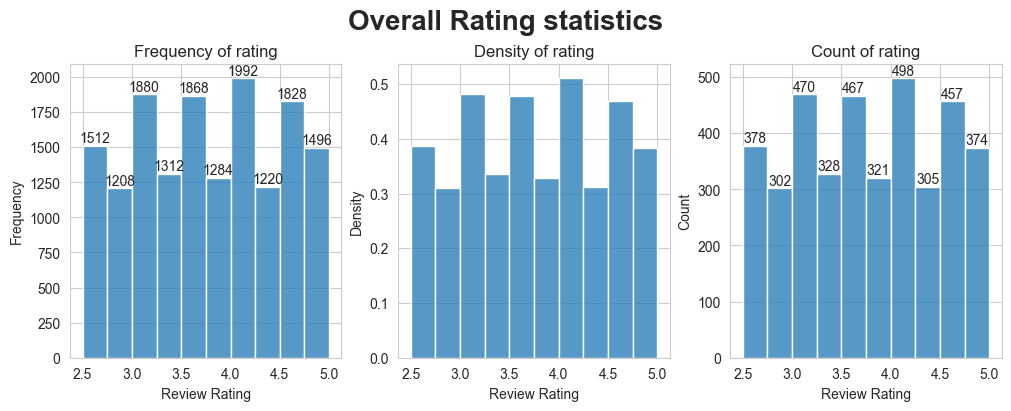

In [502]:
fig, ax = plt.subplots(ncols= 3, figsize = (10, 4), layout = "constrained")

sns.histplot(ax = ax[0], x= df["Review Rating"], bins= 10, stat = "frequency")
ax[0].bar_label(ax[0].containers[0])
ax[0].set(title = "Frequency of rating")

sns.histplot(ax = ax[1], x= df["Review Rating"], bins= 10, stat = "density")
# ax[1].bar_label(round(ax[1].containers[0], ))
# for i in ax[1].containers:
#     ax[1].bar_label(i)
ax[1].set(title = "Density of rating")

sns.histplot(ax = ax[2], x= df["Review Rating"], bins= 10)
ax[2].bar_label(ax[2].containers[0])
ax[2].set(title = "Count of rating")
chart_agg.append(fig)
fig.suptitle("Overall Rating statistics", fontsize = 20, fontweight = 'bold')
plt.show()

,mean,max,min,25 Percentile,50 Percentile,70 Percentile
Category,,,,,,
Accessories,3.770242,5.0,2.5,3.2,3.8,4.4
Clothing,3.721301,5.0,2.5,3.1,3.7,4.3
Footwear,3.793823,5.0,2.5,3.2,3.8,4.4
Outerwear,3.745988,5.0,2.5,3.1,3.8,4.3


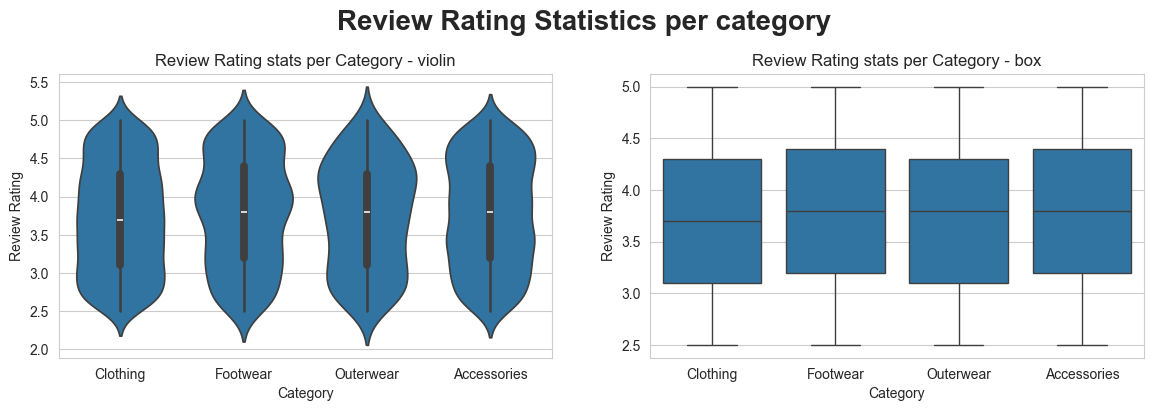

In [503]:
# purchase amount (USD) distribution by Category
stat_review = df.groupby(["Category"])["Review Rating"].aggregate(["mean", "max", "min", ("25 Percentile", lambda x : x.quantile(0.25)), ("50 Percentile", lambda x : x.quantile(0.50)), ("70 Percentile", lambda x : x.quantile(0.75))])

fig, ax = plt.subplots(ncols= 2, figsize = (14, 4))
sns.violinplot(ax = ax[0], data = df, x = "Category", y = "Review Rating")
ax[0].set_title("Review Rating stats per Category - violin")

sns.boxplot(ax = ax[1], data = df, x = "Category", y = "Review Rating")
ax[1].set_title("Review Rating stats per Category - box")
display(stat_review)
fig.suptitle("Review Rating Statistics per category", fontsize = 20, fontweight = "bold")
fig.subplots_adjust(top= 0.82)
chart_agg.append(fig)
plt.show()

In [504]:
def item_cate(df):
    df["cate_group"] = np.zeros(len(df), dtype = "int")
    # print(df)
    for i in range(1, int(df["Review Rating"].max()) + 1):
        d = df[(df["Review Rating"] >= i) & (df["Review Rating"] < i + 1)]
        df.loc[d.index, "cate_group"] =  i
    return df
        # df.loc[d.index]["cate"] = d["cate"] + i

In [505]:
item_rate = df[["Item Purchased", "Review Rating"]].sort_values(["Item Purchased", "Review Rating"], ascending= [True, True])
cate_item = item_cate(item_rate)
cate_item

,Item Purchased,Review Rating,cate_group
318,Backpack,2.5,2
414,Backpack,2.6,2
617,Backpack,2.6,2
768,Backpack,2.6,2
2868,Backpack,2.6,2
...,...,...,...
1805,T-shirt,4.9,4
1827,T-shirt,4.9,4
2835,T-shirt,4.9,4
3864,T-shirt,4.9,4


In [506]:
cate_item_group = cate_item.groupby(["Item Purchased", "cate_group"]).count().reset_index()
cate_item_group

,Item Purchased,cate_group,Review Rating
0,Backpack,2,21
1,Backpack,3,64
2,Backpack,4,57
3,Backpack,5,1
4,Belt,2,26
...,...,...,...
94,Sweater,5,1
95,T-shirt,2,23
96,T-shirt,3,59
97,T-shirt,4,64


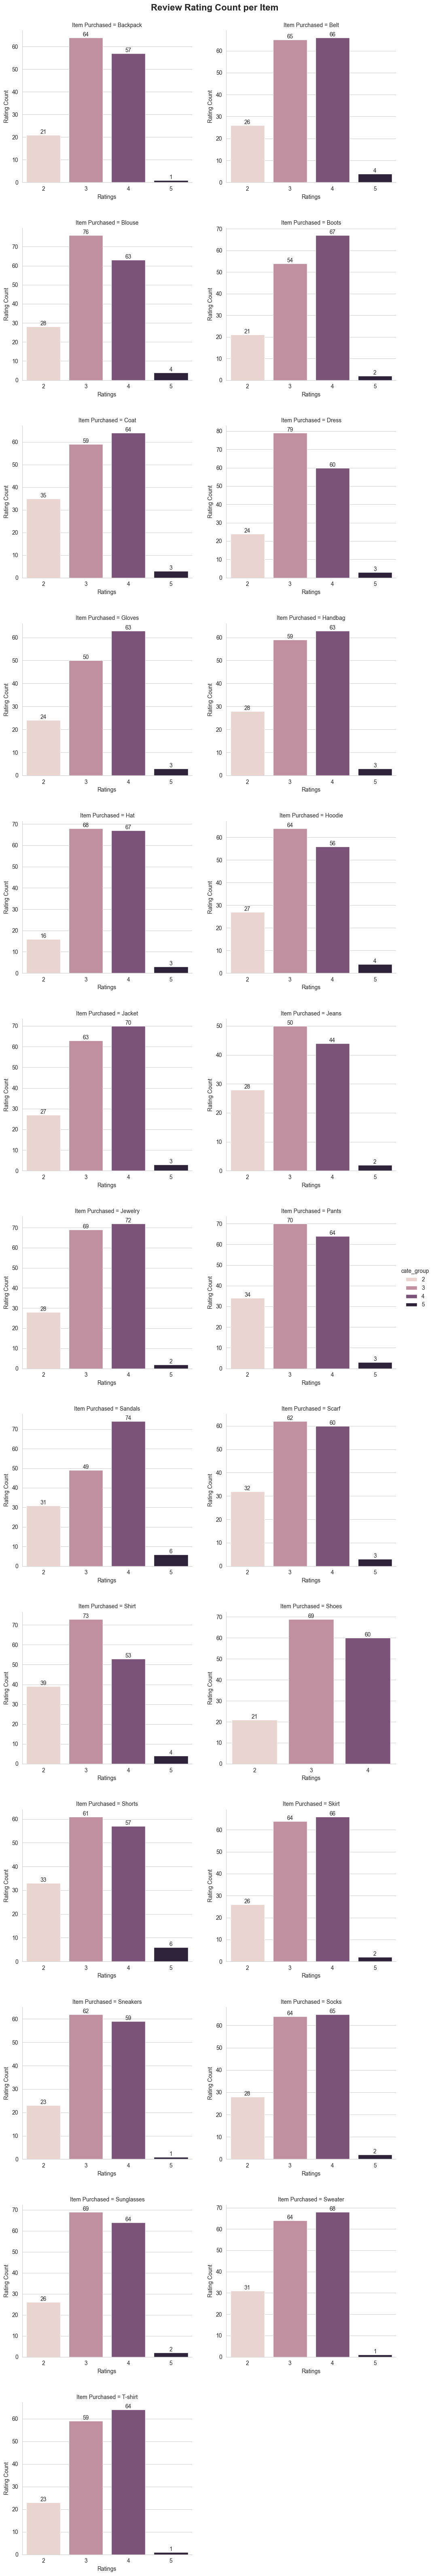

In [507]:
ax = sns.catplot(data = cate_item_group,
    x = "cate_group", 
    y = "Review Rating", 
    hue = "cate_group", 
    col = "Item Purchased", 
    kind = "bar", col_wrap= 2, sharex= False, sharey= False)

for i in ax.axes.flat:
    for j in i.containers:
        i.bar_label(j)
    i.set_ylabel("Rating Count")
    i.set_xlabel("Ratings")
plt.suptitle("Review Rating Count per Item", fontsize = 16, fontweight = "bold")
plt.subplots_adjust(hspace= 0.3, wspace = 0.2, top = 0.97)
chart_agg.append(plt.gcf())
plt.show()

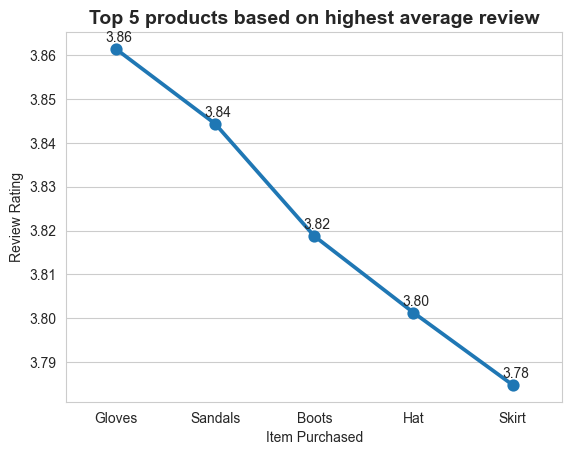

In [508]:
item_review = df.groupby(["Item Purchased"])["Review Rating"].agg("mean").reset_index().sort_values("Review Rating", ascending = False).head()
sns.pointplot(data= item_review, x = "Item Purchased", y = "Review Rating")
# plt.fill_between(item_review["Item Purchased"], item_review["Review Rating"])b
for i, j in zip(item_review["Item Purchased"], item_review["Review Rating"]):
    plt.annotate(f"{j:.2f}", (i, j), textcoords = "offset points", xytext= (2, 5),ha = "center")
plt.title("Top 5 products based on highest average review", fontsize = 14, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()


In [509]:
item_Cat_review = df.groupby(["Category", "Item Purchased"])["Review Rating"].agg([("Average Ratings", "mean"), "min", "max"]).reset_index()
top_3 = item_Cat_review.groupby("Category", group_keys = False).apply(lambda x : x.nlargest(3, "Average Ratings"))
top_3

C:\Users\DELL\AppData\Local\Temp\ipykernel_7788\354896750.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_3 = item_Cat_review.groupby("Category", group_keys = False).apply(lambda x : x.nlargest(3, "Average Ratings"))


,Category,Item Purchased,Average Ratings,min,max
2,Accessories,Gloves,3.861429,2.5,5.0
4,Accessories,Hat,3.801299,2.5,5.0
3,Accessories,Handbag,3.775163,2.5,5.0
15,Clothing,Skirt,3.784810,2.5,5.0
18,Clothing,T-shirt,3.778231,2.5,5.0
17,Clothing,Sweater,3.759756,2.5,5.0
20,Footwear,Sandals,3.844375,2.5,5.0
19,Footwear,Boots,3.818750,2.5,5.0
22,Footwear,Sneakers,3.757931,2.5,5.0
24,Outerwear,Jacket,3.763190,2.5,5.0


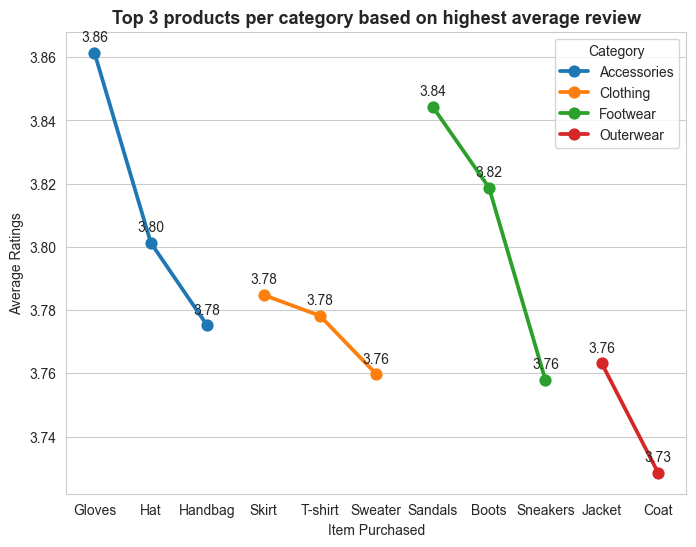

In [510]:
plt.figure(figsize = (8, 6))
sns.pointplot(data= top_3, x = "Item Purchased", y = "Average Ratings", hue = "Category")
plt.title("Top 3 products per category based on highest average review", fontsize = 13, fontweight = "bold")
for x, y in zip(top_3["Item Purchased"], top_3["Average Ratings"]):
    plt.annotate(
        f"{y:.2f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )
chart_agg.append(plt.gcf())
plt.show()

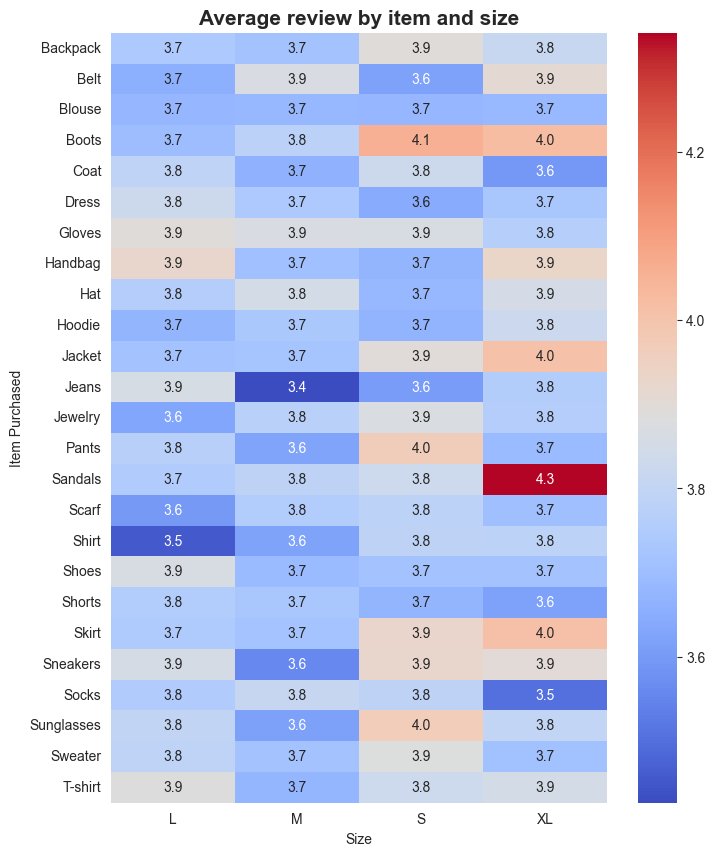

In [511]:
# Average review by item and size
item_size_review = df.pivot_table(index="Item Purchased", columns = "Size", values = "Review Rating", aggfunc= "mean")
# size_purchase
plt.figure(figsize=(8, 10))
sns.heatmap(data = item_size_review, annot=True, fmt=".01f", cmap="coolwarm")

plt.title("Average review by item and size", fontsize = 15, fontweight = "bold")
chart_agg.append(plt.gcf())
plt.show()

## Consumer Spending Analysis by Age

In [512]:
df["Age"].value_counts().sort_index().reset_index().head()

,Age,count
0,18,69
1,19,81
2,20,62
3,21,69
4,22,66


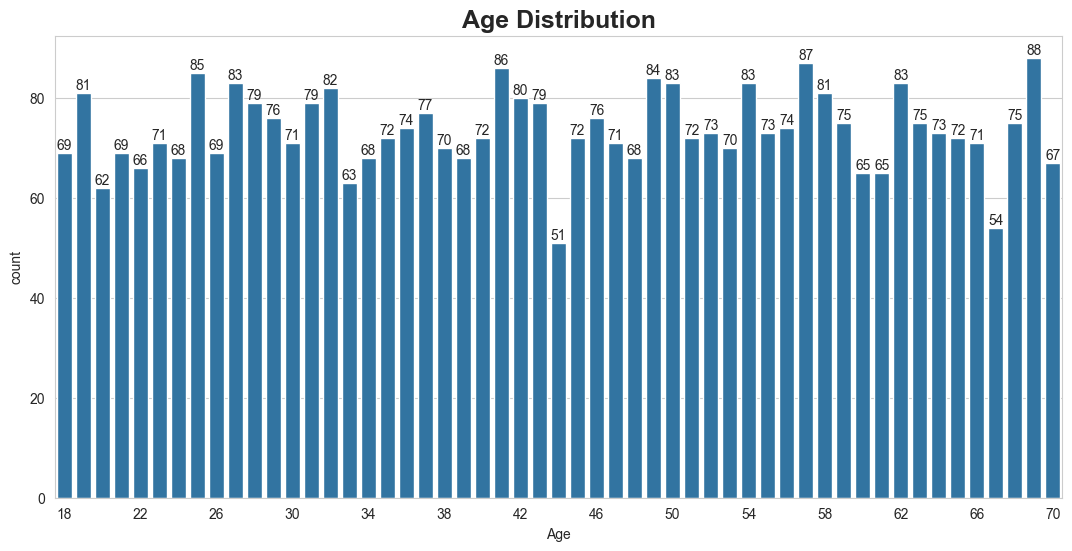

In [513]:
plt.figure(figsize= (13, 6))
ax = sns.countplot(data=df, x="Age")
plt.title("Age Distribution", fontsize = 18, fontweight = 'bold')
ax.set_xticks(ax.get_xticks()[::4])
ax.bar_label(ax.containers[0])
chart_agg.append(plt.gcf())
plt.show()

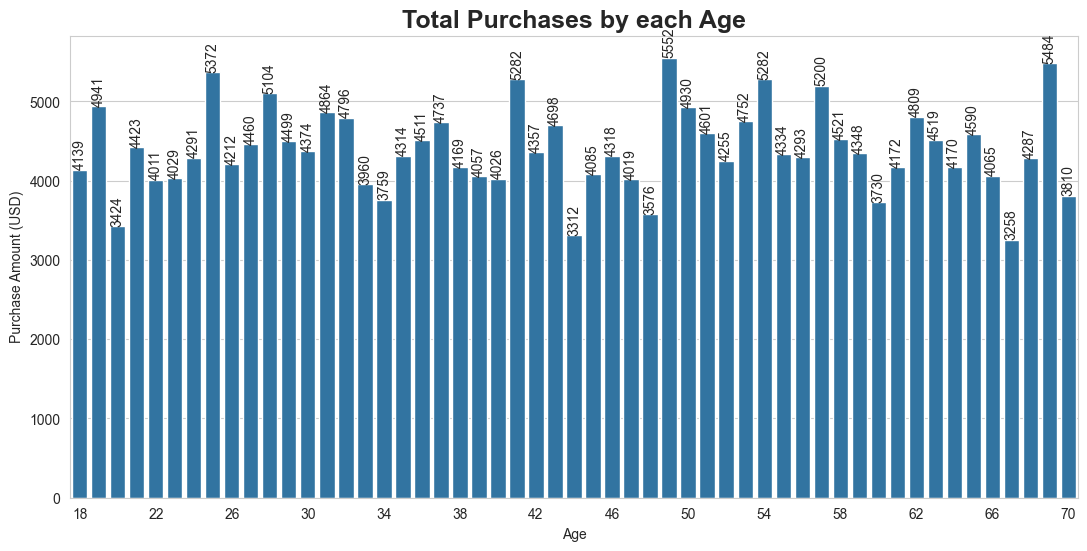

In [514]:
# # total revenue generated by male vs. female customers
age_TotaPur = df.groupby(["Age"])["Purchase Amount (USD)"].sum().reset_index()
age_TotaPur.head()
plt.figure(figsize= (13, 6))
ax = sns.barplot(data=age_TotaPur, x="Age", y = "Purchase Amount (USD)")
plt.title("Total Purchases by each Age", fontsize = 18, fontweight = 'bold')
ax.bar_label(ax.containers[0], rotation = 90)
ax.set_xticks(ax.get_xticks()[::4])
chart_agg.append(plt.gcf())
plt.show()

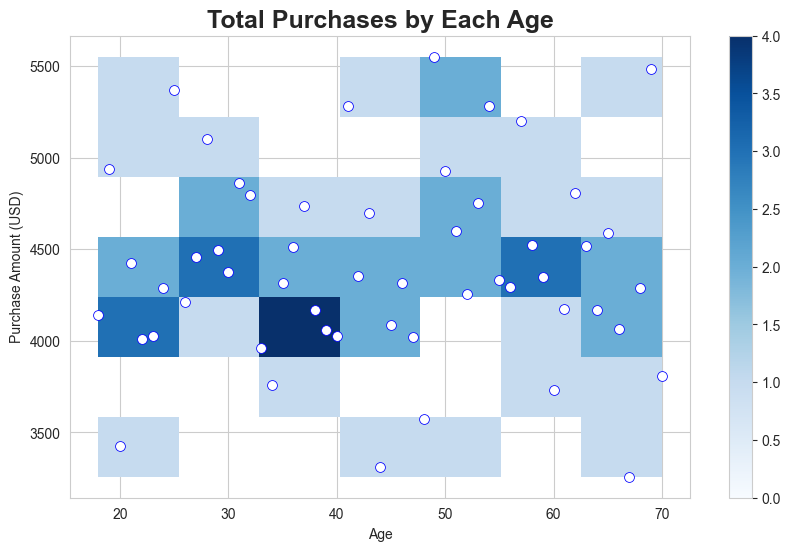

In [515]:
plt.figure(figsize=(10,6))

sns.histplot(data=age_TotaPur, x="Age", y="Purchase Amount (USD)", cbar=True, cmap="Blues")

sns.scatterplot(data=age_TotaPur,x="Age",y="Purchase Amount (USD)",facecolor="white",edgecolor="blue",s=50)

plt.title("Total Purchases by Each Age", fontsize = 18, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()

In [516]:
# age_TotaPur.groupby(pd.cut(age_TotaPur['Age'], bins=np.linspace(18, 70, 8).astype(int), labels = ['18-25', '26-32', '33-40', '41-47', '48-55', '56-62', '63-70'], right=True, include_lowest=True))['Purchase Amount (USD)'].sum().reset_index()

In [517]:
def labels_inter(num):
    intr = []
    for j in range(1,len(num)):
        if j != 1:
            x = y + 1
        else:
            x = num[j-1]
        y = num[j]
        intr.append(f"{x}-{y}")
    return pd.Series(intr)
bins = np.linspace(18, 70, 8).astype(int)
# divide into age groups
age_group = pd.cut(df['Age'], bins= bins, labels = labels_inter(bins), right=True, include_lowest=True)

pur_ageGroup = df.groupby(age_group)['Purchase Amount (USD)'].agg([("Total count", "count"), ("Total sales", "sum")])
pur_ageGroup

C:\Users\DELL\AppData\Local\Temp\ipykernel_7788\1735122847.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pur_ageGroup = df.groupby(age_group)['Purchase Amount (USD)'].agg([("Total count", "count"), ("Total sales", "sum")])


,Total count,Total sales
Age,,
18-25,571,34630
26-32,539,32309
33-40,564,33533
41-47,515,30071
48-55,606,37282
56-62,530,31073
63-70,575,34183


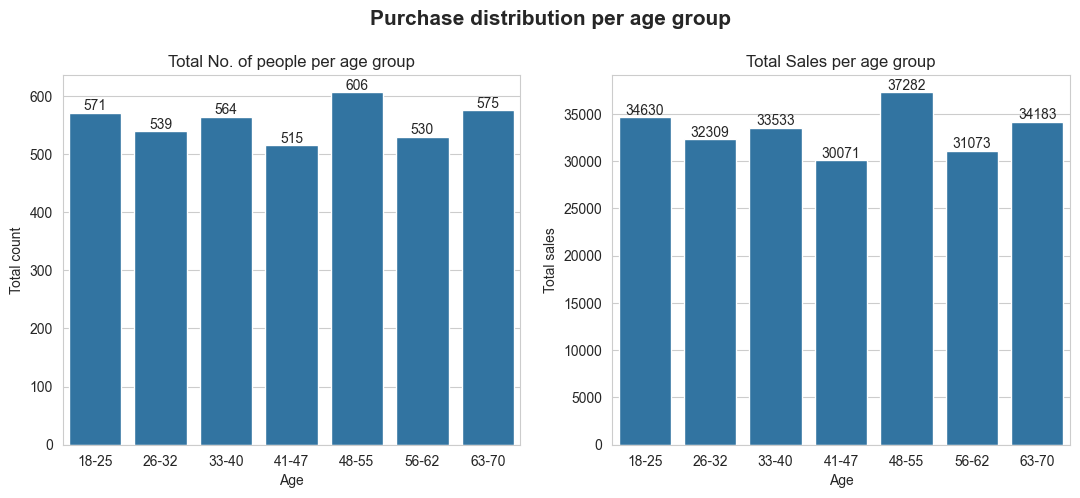

In [518]:
fig, ax = plt.subplots(ncols= 2, figsize = (13, 5))

sns.barplot(ax = ax[0], data  = pur_ageGroup, x = "Age", y = "Total count")
ax[0].bar_label(ax[0].containers[0])
ax[0].set_title("Total No. of people per age group")

sns.barplot(ax = ax[1], data  = pur_ageGroup, x = "Age", y = "Total sales")
ax[1].bar_label(ax[1].containers[0])
ax[1].set_title("Total Sales per age group")
fig.suptitle("Purchase distribution per age group", fontsize = 15, fontweight = 'bold')
fig.subplots_adjust(top = 0.85)
chart_agg.append(fig)
plt.show()

In [519]:
# total revenue generated by male vs. female customers
age_Cate_Pu = df.groupby([age_group, "Category"])["Purchase Amount (USD)"].sum().reset_index()
age_Cate_Pu

C:\Users\DELL\AppData\Local\Temp\ipykernel_7788\3827258638.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_Cate_Pu = df.groupby([age_group, "Category"])["Purchase Amount (USD)"].sum().reset_index()


,Age,Category,Purchase Amount (USD)
0,18-25,Accessories,10511
1,18-25,Clothing,16221
2,18-25,Footwear,4849
3,18-25,Outerwear,3049
4,26-32,Accessories,10331
5,26-32,Clothing,15125
6,26-32,Footwear,4933
7,26-32,Outerwear,1920
8,33-40,Accessories,11669
9,33-40,Clothing,13739


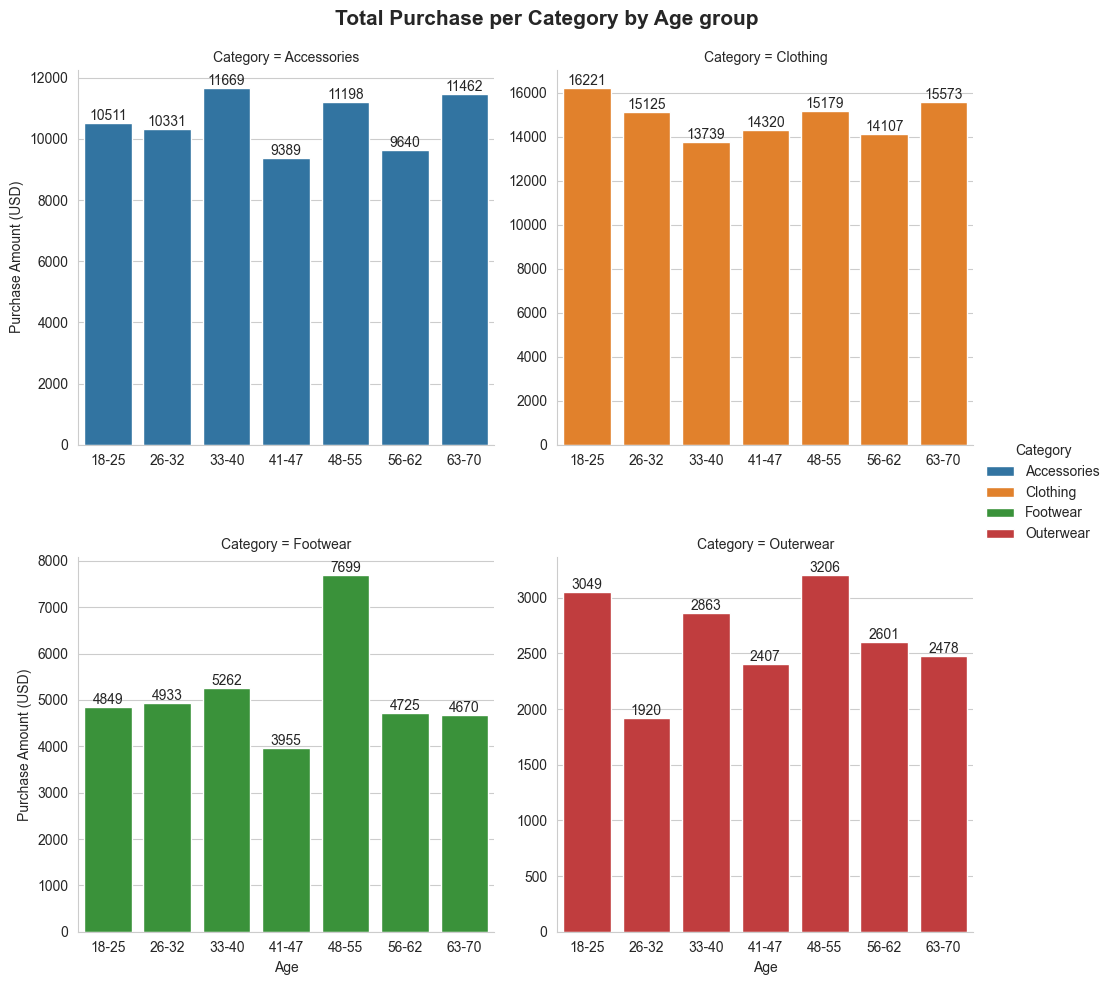

In [520]:
ax = sns.catplot(data = age_Cate_Pu, x = "Age", y = "Purchase Amount (USD)", hue = "Category", kind = "bar", col = "Category", sharey= False, sharex = False, col_wrap= 2)
plt.suptitle("Total Purchase per Category by Age group", fontsize = 15, fontweight = 'bold')
plt.subplots_adjust(hspace = 0.3, top = 0.92)
for i in ax.axes.flat:
    for j in i.containers:
        i.bar_label(j)
chart_agg.append(plt.gcf())
plt.show()

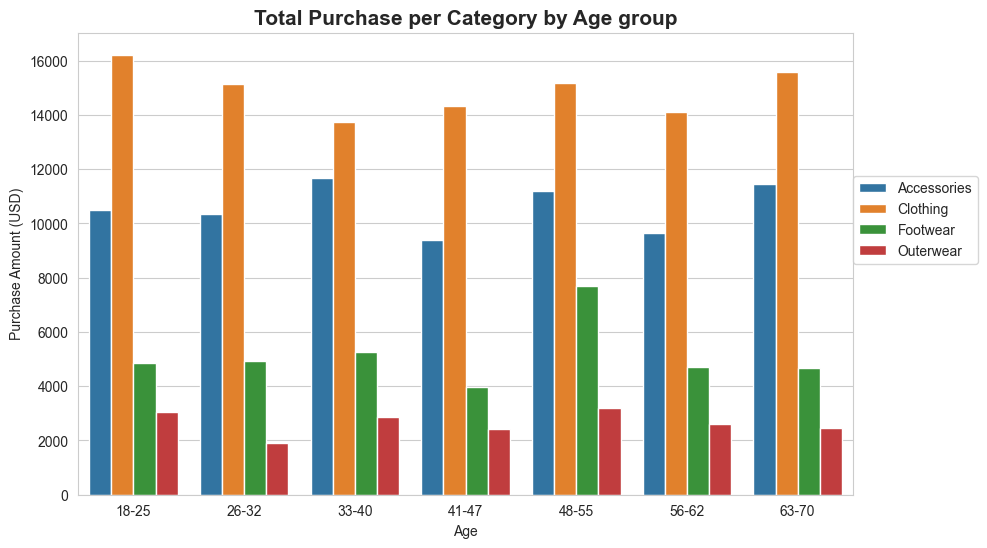

In [521]:
plt.figure(figsize= (10, 6))
sns.barplot(data = age_Cate_Pu, x = "Age", y = "Purchase Amount (USD)", hue = "Category")
plt.title("Total Purchase per Category by Age group", fontsize = 15, fontweight = "bold")
plt.legend(loc =[1, 0.5])
chart_agg.append(plt.gcf())
plt.show()

In [522]:
table_cate = age_Cate_Pu.pivot_table(index="Category", columns="Age", values="Purchase Amount (USD)", aggfunc="sum", observed=True)
table_cate

Age,18-25,26-32,33-40,41-47,48-55,56-62,63-70
Category,,,,,,,
Accessories,10511,10331,11669,9389,11198,9640,11462
Clothing,16221,15125,13739,14320,15179,14107,15573
Footwear,4849,4933,5262,3955,7699,4725,4670
Outerwear,3049,1920,2863,2407,3206,2601,2478


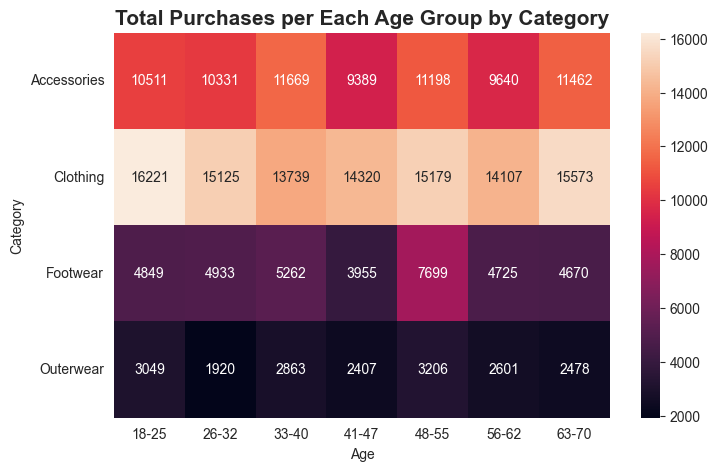

In [523]:
plt.figure(figsize=(8, 5))
sns.heatmap(table_cate, annot=True, fmt="1")
plt.title("Total Purchases per Each Age Group by Category", fontsize = 15, fontweight = 'bold')
plt.tick_params(axis = "y", rotation = 0)
chart_agg.append(plt.gcf())
plt.show()

In [524]:
age_item_Pu = df.groupby([age_group, "Item Purchased"])["Purchase Amount (USD)"].sum().reset_index()
age_item_Pu

C:\Users\DELL\AppData\Local\Temp\ipykernel_7788\3479456391.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_item_Pu = df.groupby([age_group, "Item Purchased"])["Purchase Amount (USD)"].sum().reset_index()


,Age,Item Purchased,Purchase Amount (USD)
0,18-25,Backpack,922
1,18-25,Belt,1476
2,18-25,Blouse,1382
3,18-25,Boots,1235
4,18-25,Coat,1802
...,...,...,...
170,63-70,Sneakers,1066
171,63-70,Socks,1583
172,63-70,Sunglasses,1040
173,63-70,Sweater,1271


In [525]:
top3_total_sale_perAgegroup = age_item_Pu.groupby(["Age"], group_keys= False).apply(lambda x : x.nlargest(3, "Purchase Amount (USD)"))
top3_total_sale_perAgegroup

C:\Users\DELL\AppData\Local\Temp\ipykernel_7788\2030360409.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top3_total_sale_perAgegroup = age_item_Pu.groupby(["Age"], group_keys= False).apply(lambda x : x.nlargest(3, "Purchase Amount (USD)"))
C:\Users\DELL\AppData\Local\Temp\ipykernel_7788\2030360409.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top3_total_sale_perAgegroup = age_item_Pu.groupby(["Age"], group_keys= False).apply(lambda x : x.nlargest(3, "Purchase Amount (USD)"))


,Age,Item Purchased,Purchase Amount (USD)
5,18-25,Dress,1917
4,18-25,Coat,1802
23,18-25,Sweater,1780
41,26-32,Shirt,2126
42,26-32,Shoes,1875
25,26-32,Backpack,1700
62,33-40,Jewelry,1823
60,33-40,Jacket,1736
63,33-40,Pants,1733
90,41-47,Scarf,1973


<Figure size 900x700 with 0 Axes>

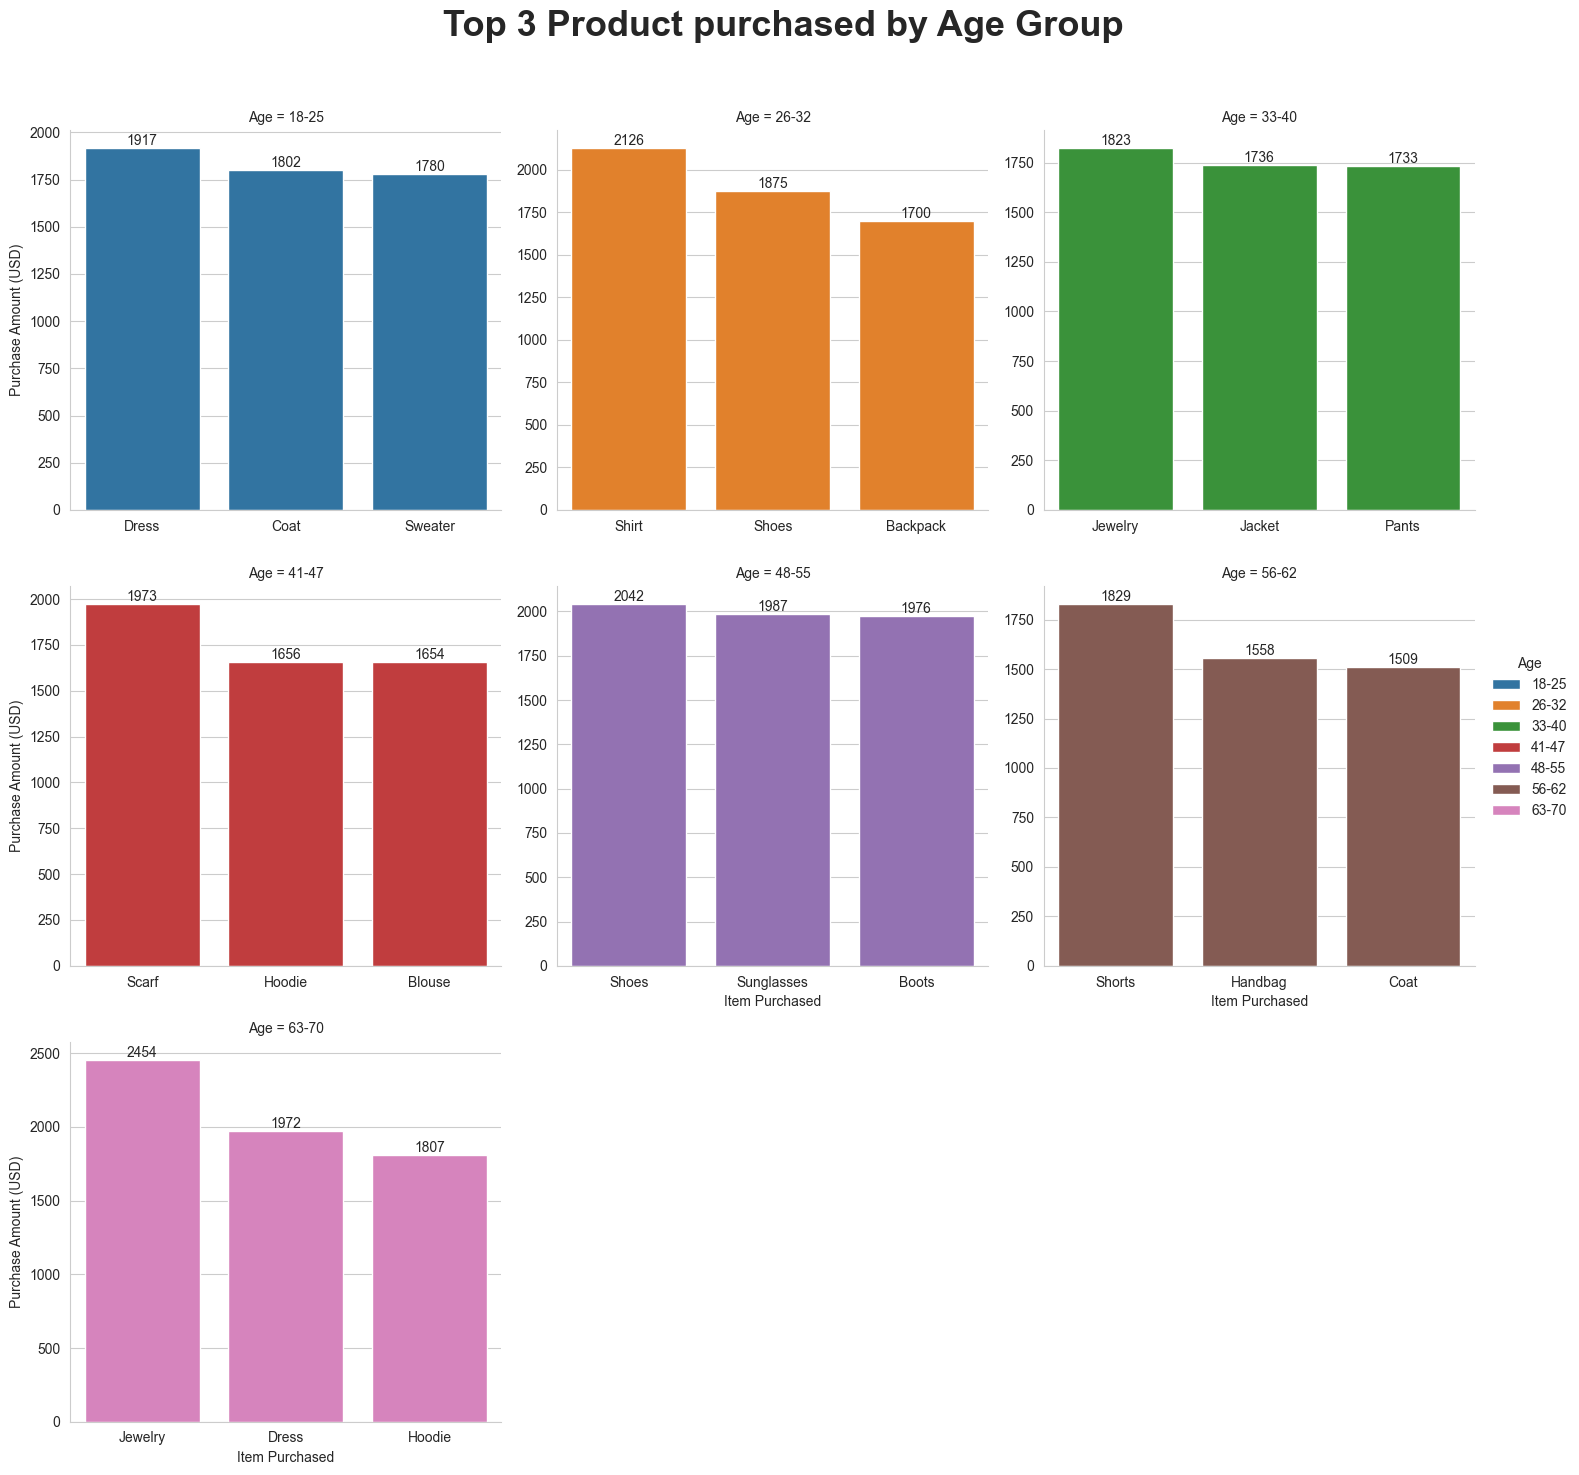

In [526]:
plt.figure(figsize = (9, 7))
ax = sns.catplot(data = top3_total_sale_perAgegroup, x = "Item Purchased", y = "Purchase Amount (USD)", hue= "Age", kind = "bar", col = "Age", col_wrap = 3, sharex= False, sharey= False)
# plt.legend(loc = [1, 0.5])
for i in ax.axes.flat:
    for j in i.containers:
        i.bar_label(j)
plt.suptitle("Top 3 Product purchased by Age Group", fontsize= 26, fontweight = "bold")
plt.subplots_adjust(hspace= 0.2, top = 0.90)
chart_agg.append(plt.gcf())
plt.show()

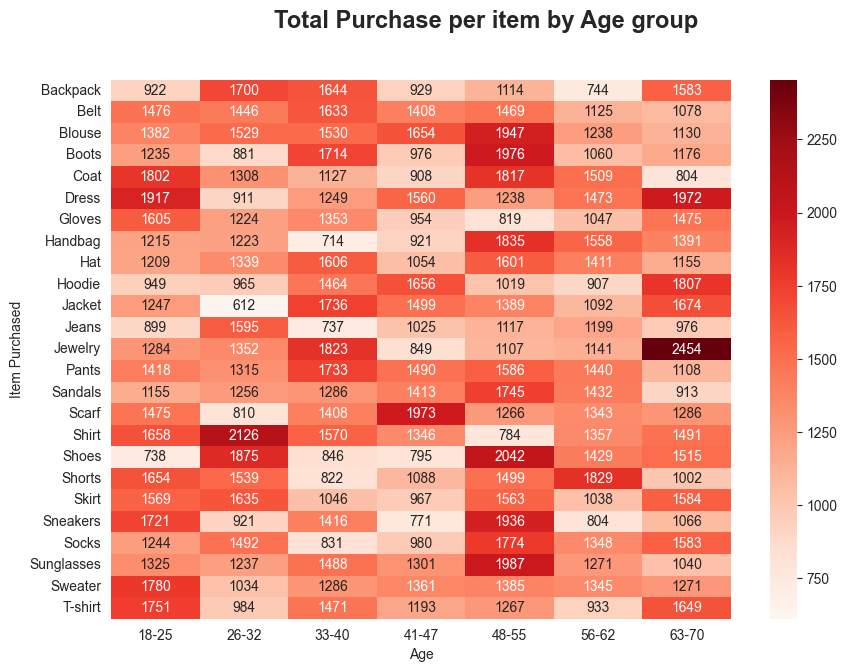

In [527]:
table_item = age_item_Pu.pivot_table(index="Item Purchased", columns="Age", values="Purchase Amount (USD)", aggfunc="sum", observed=True)
plt.figure(figsize=(10, 7))
sns.heatmap(table_item, annot=True, fmt="1", cmap="Reds")
plt.suptitle("Total Purchase per item by Age group", fontsize = 17, fontweight = "bold")
chart_agg.append(plt.gcf())
plt.show()

## Shipping Type Analysis

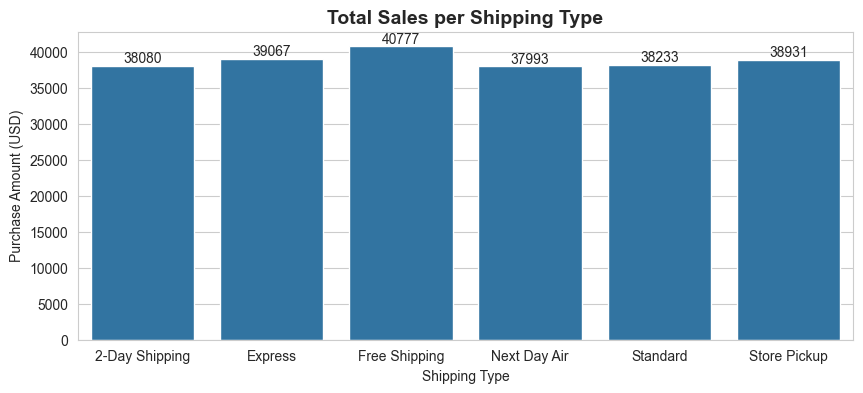

In [528]:
# Compare the average Purchase Amounts between Standard and Express Shipping.
plt.figure(figsize=(10,4))
av_pu = df.groupby([df["Shipping Type"]])["Purchase Amount (USD)"].sum().reset_index()
ax = sns.barplot(data = av_pu, x = "Shipping Type", y = "Purchase Amount (USD)")
ax.bar_label(ax.containers[0])
plt.title("Total Sales per Shipping Type", fontsize = 14, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()

## Payment Method Analysis

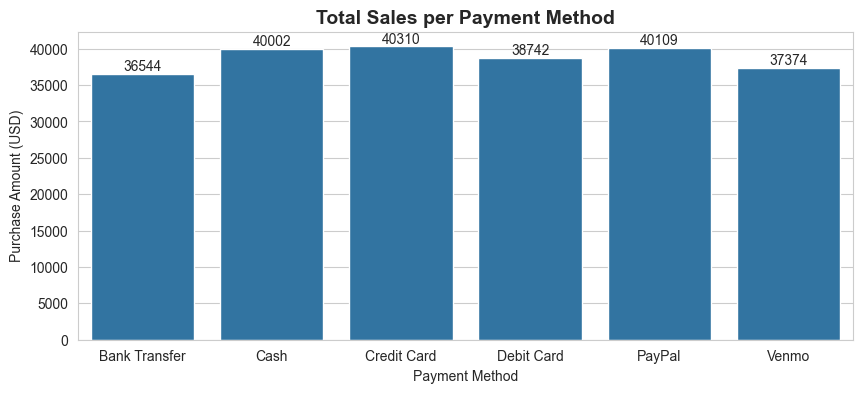

In [529]:
plt.figure(figsize=(10,4))
av_pu = df.groupby([df["Payment Method"]])["Purchase Amount (USD)"].sum().reset_index()
ax = sns.barplot(data = av_pu, x = "Payment Method", y = "Purchase Amount (USD)")
ax.bar_label(ax.containers[0])
plt.title("Total Sales per Payment Method", fontsize = 14, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()

In [530]:
# Which 5 products have the highest percentage of purchases with discounts applied?

item_Pu = df.groupby([df[df["Discount Applied"] == "Yes"]["Discount Applied"], "Item Purchased"], as_index= False)["Purchase Amount (USD)"].sum().sort_values("Purchase Amount (USD)", ascending= False)
item_Pu["Percentage"] = ((item_Pu["Purchase Amount (USD)"] / item_Pu["Purchase Amount (USD)"].sum()) * 100).round(3)
top_5 = item_Pu.head()
top_5

C:\Users\DELL\AppData\Local\Temp\ipykernel_7788\1809462722.py:3: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  item_Pu = df.groupby([df[df["Discount Applied"] == "Yes"]["Discount Applied"], "Item Purchased"], as_index= False)["Purchase Amount (USD)"].sum().sort_values("Purchase Amount (USD)", ascending= False)


,Item Purchased,Purchase Amount (USD),Percentage
13,Pants,4837,4.866
23,Sweater,4610,4.637
8,Hat,4596,4.623
4,Coat,4470,4.496
5,Dress,4368,4.394


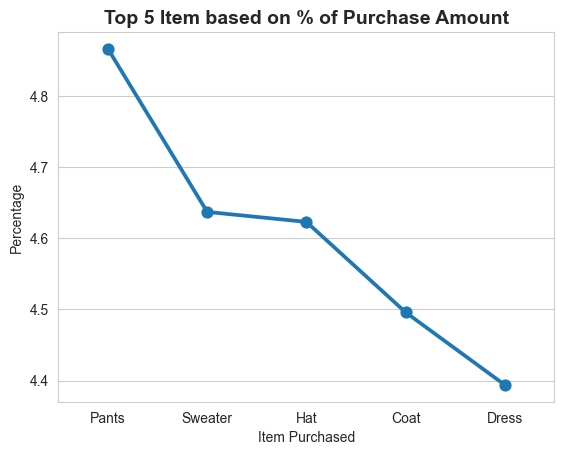

In [531]:
sns.pointplot(data = top_5, x = "Item Purchased", y= "Percentage")
plt.title("Top 5 Item based on % of Purchase Amount", fontsize = 14, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()

## Customer Segmentation by Purchase Frequency Analysis

In [532]:
# Segment customers into New, Returning, and Loyal based on their total number of previous purchases, and show the count of each segment. 
condition = [(df["Previous Purchases"] == 1),((df["Previous Purchases"] > 1) & (df["Previous Purchases"] <= 10)),
            (df["Previous Purchases"] > 10)]
pur_seg = ["New", "Returning", "Loyal"]
df["Prev_purchase_seg"] = np.select(condition, pur_seg, "no")

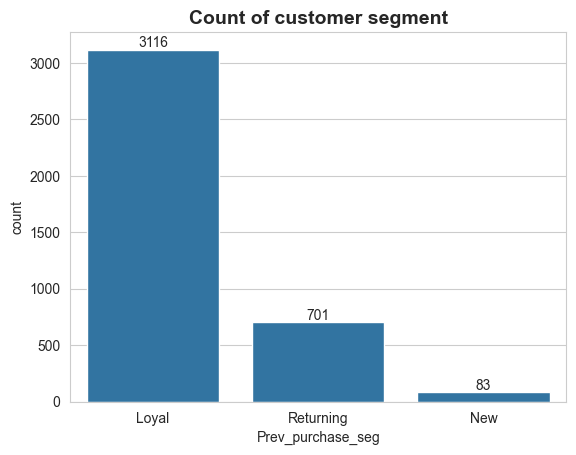

In [533]:
pre_seg = df["Prev_purchase_seg"].value_counts().reset_index()
ax = sns.barplot(data = pre_seg, x = "Prev_purchase_seg", y = "count")
plt.bar_label(ax.containers[0])
plt.title("Count of customer segment", fontsize = 14, fontweight = 'bold')
chart_agg.append(plt.gcf())
plt.show()

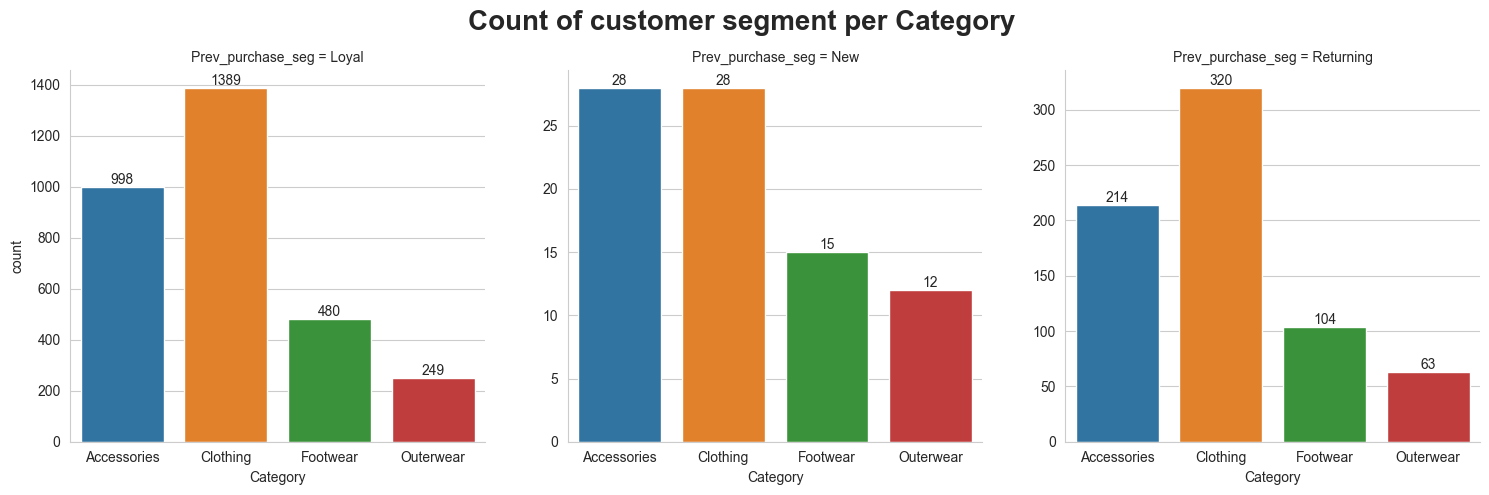

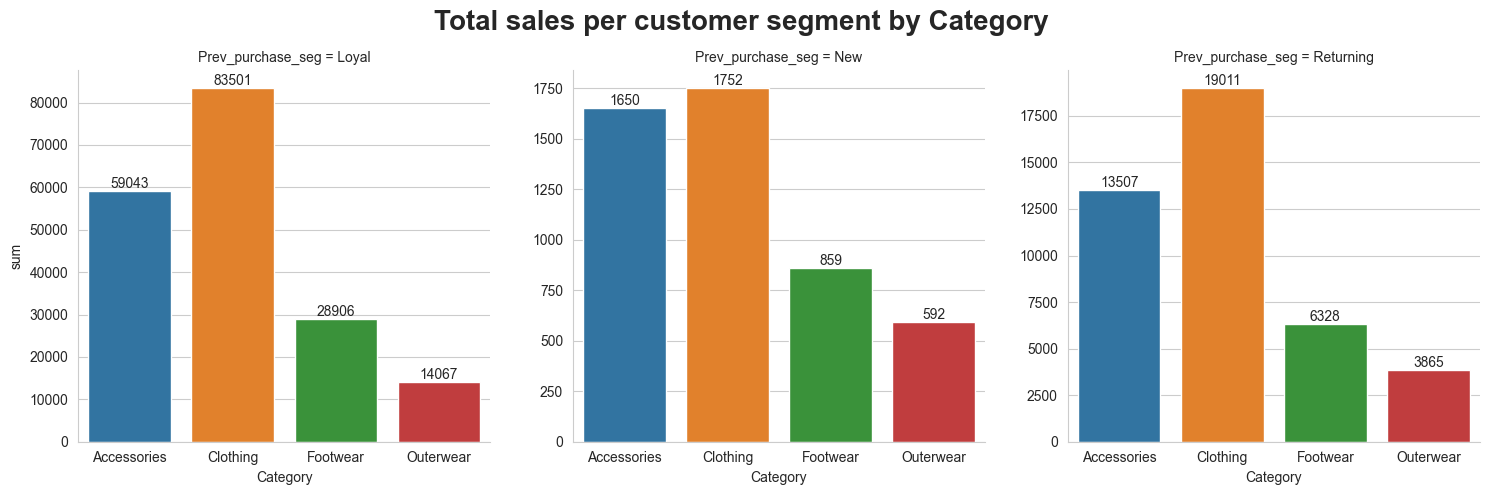

In [534]:
pre_seg = df.groupby(["Prev_purchase_seg", "Category"])["Purchase Amount (USD)"].agg(["sum", "count"]).reset_index()
ax = sns.catplot(data = pre_seg, x = "Category", y = "count",  hue = "Category", kind = "bar", col = "Prev_purchase_seg", col_wrap=3, sharex= False, sharey= False)
for i in ax.axes.flat:
    for j in i.containers:
        i.bar_label(j, fontsize=10)
ax.fig.suptitle("Count of customer segment per Category ", fontsize = 20, fontweight = 'bold')
plt.subplots_adjust(hspace= 0.3, wspace= 0.2, top = 0.86)
chart_agg.append(plt.gcf())

ax = sns.catplot(data = pre_seg, x = "Category", y = "sum",  hue = "Category", kind = "bar", col = "Prev_purchase_seg", col_wrap=3, sharex= False, sharey= False)
for i in ax.axes.flat:
    for j in i.containers:
        i.bar_label(j, fontsize=10)
ax.fig.suptitle("Total sales per customer segment by Category ", fontsize = 20, fontweight = 'bold')
plt.subplots_adjust(hspace= 0.3, wspace= 0.2, top = 0.86)
chart_agg.append(plt.gcf())
plt.show()

## Purchase Frequency analysis

In [535]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['Frequency of Purchases'].map(frequency_mapping)

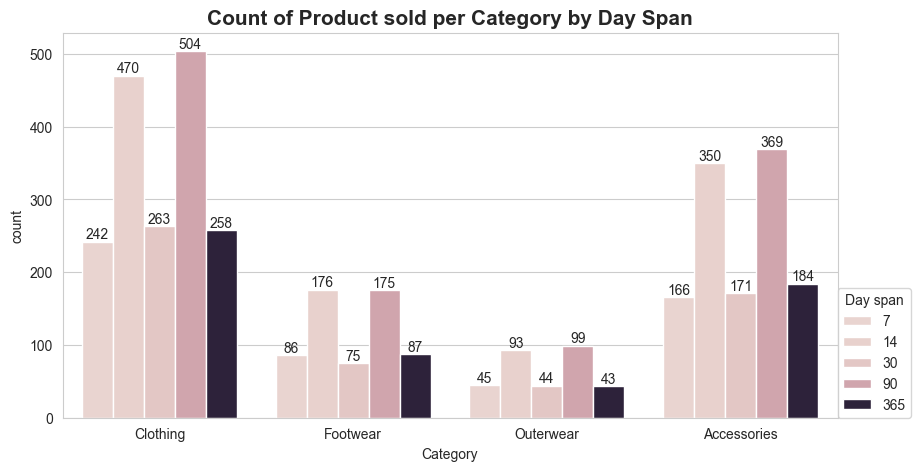

In [536]:
plt.figure(figsize= (10, 5))
ax = sns.countplot(data = df, x = "Category", hue = "purchase_frequency_days")
for i in ax.containers:
    ax.bar_label(i)
plt.legend(loc = [1, 0], title = "Day span")
plt.title("Count of Product sold per Category by Day Span", fontsize = 15, fontweight = "bold")
chart_agg.append(plt.gcf())
plt.show()

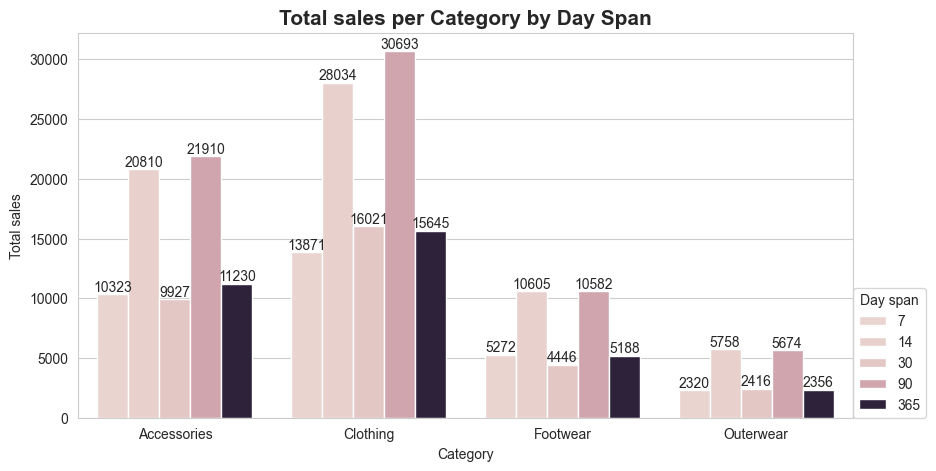

In [537]:
sum_day = df.groupby(["Category", "purchase_frequency_days"])["Purchase Amount (USD)"].agg([("Total sales", "sum")]).reset_index()
plt.figure(figsize= (10, 5))
ax = sns.barplot(data = sum_day, x = "Category", y = 'Total sales', hue = "purchase_frequency_days")
for i in ax.containers:
    ax.bar_label(i)
plt.legend(loc = [1, 0], title = "Day span")
plt.title("Total sales per Category by Day Span", fontsize = 15, fontweight = "bold")
chart_agg.append(plt.gcf())
plt.show()

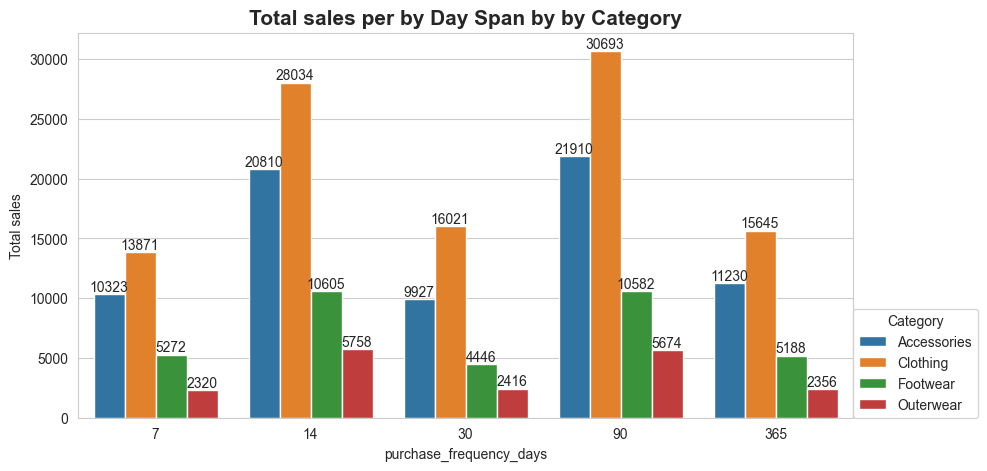

In [538]:
plt.figure(figsize= (10, 5))
ax = sns.barplot(data = sum_day, x = "purchase_frequency_days", y = 'Total sales', hue = "Category")
for i in ax.containers:
    ax.bar_label(i)
plt.legend(loc = [1, 0], title = "Category")
plt.title("Total sales per by Day Span by by Category", fontsize = 15, fontweight = "bold")
chart_agg.append(plt.gcf())
plt.show()

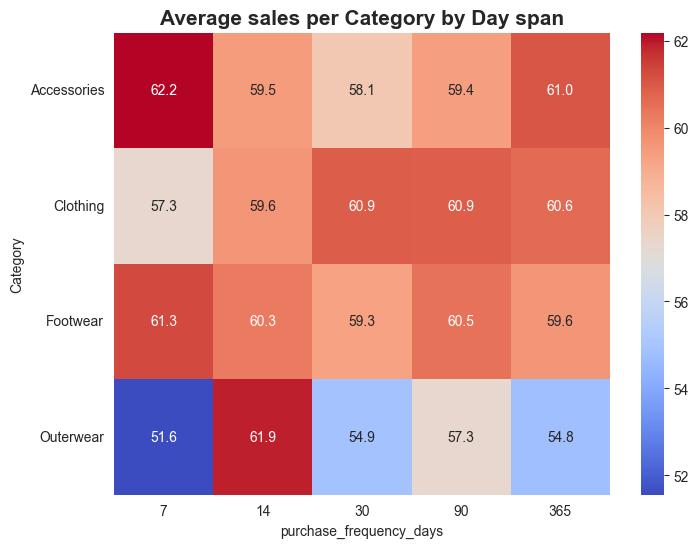

In [539]:
plt.figure(figsize= (8, 6))
mean_day = df.groupby(["Category", "purchase_frequency_days"])["Purchase Amount (USD)"].agg(["mean"]).reset_index().sort_values("mean", ascending = False)
pivot_mean = mean_day.pivot(index = "Category", columns = "purchase_frequency_days", values= "mean")
sns.heatmap(pivot_mean, annot= True, cmap = "coolwarm", fmt=  "0.1f")
plt.title("Average sales per Category by Day span", fontsize = 15, fontweight = "bold")
chart_agg.append(plt.gcf())
plt.tick_params(axis = "y", rotation = 0)
plt.show()

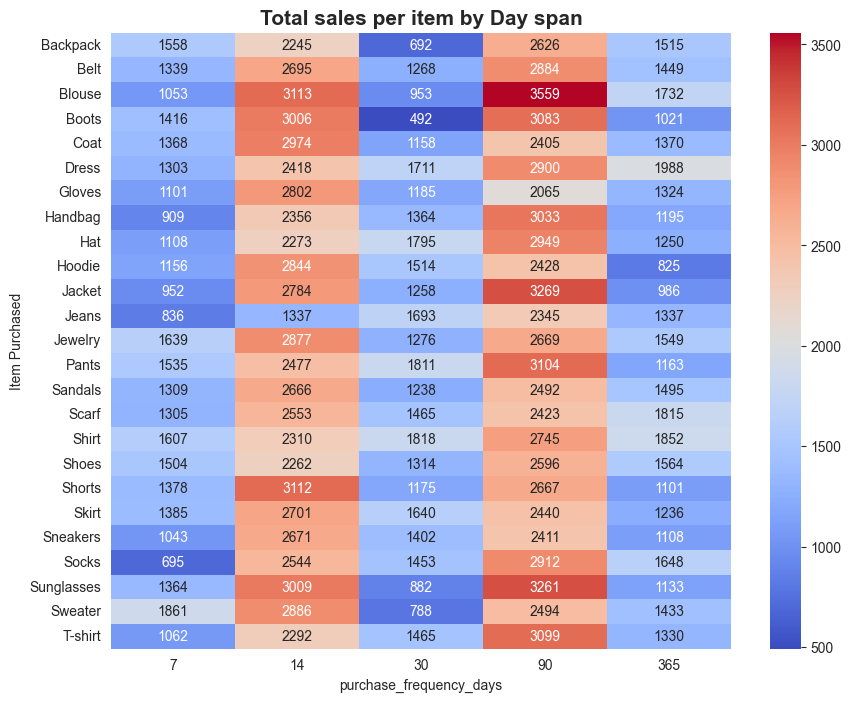

In [540]:
plt.figure(figsize= (10, 8))
sum_day = df.groupby(["Item Purchased", "purchase_frequency_days"])["Purchase Amount (USD)"].agg(["sum"]).reset_index().sort_values("sum", ascending = False)
pivot_sum = sum_day.pivot(index = "Item Purchased", columns = "purchase_frequency_days", values= "sum")
sns.heatmap(pivot_sum, annot= True, cmap = "coolwarm", fmt= "1")
plt.title("Total sales per item by Day span", fontsize = 15, fontweight = "bold")
chart_agg.append(plt.gcf())
plt.show()

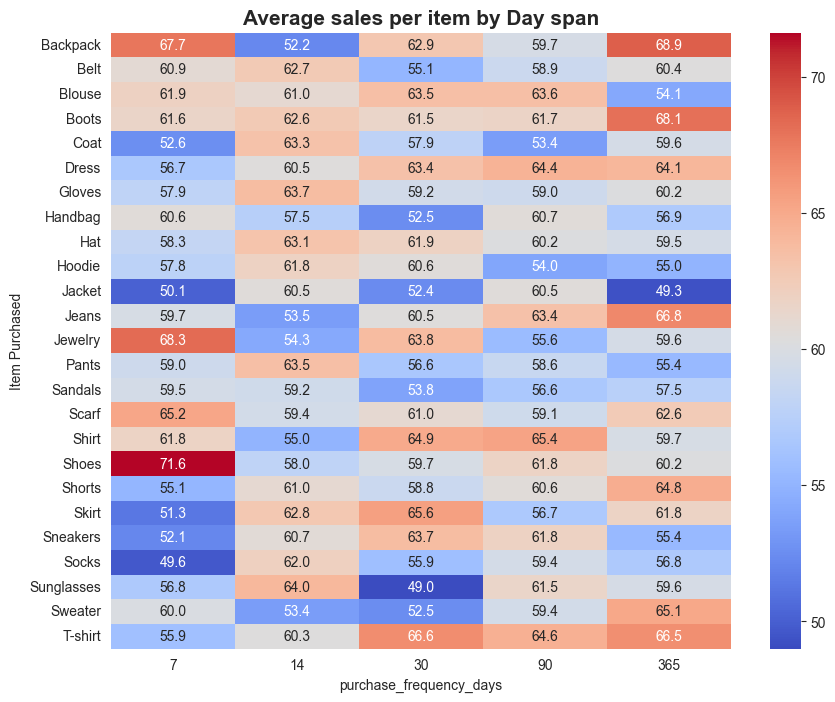

In [541]:
plt.figure(figsize= (10, 8))
mean_day = df.groupby(["Item Purchased", "purchase_frequency_days"])["Purchase Amount (USD)"].agg(["mean"]).reset_index().sort_values("mean", ascending = False)
pivot_mean = mean_day.pivot(index = "Item Purchased", columns = "purchase_frequency_days", values= "mean")
sns.heatmap(pivot_mean, annot= True, cmap = "coolwarm", fmt= "0.1f")
plt.title("Average sales per item by Day span", fontsize = 15, fontweight = "bold")
chart_agg.append(plt.gcf())
plt.show()

In [542]:
# for Getting image
from IPython.display import display
def get_image(all_fig):
    for i,j in enumerate(all_fig):
        j.savefig(f"Charts/figure_{i}.png", dpi=100, bbox_inches='tight')
        # display(fig)
get_image(chart_agg)

In [543]:
# for Getting pdf
from matplotlib.backends.backend_pdf import PdfPages
def get_pdf(all_fig):
    with PdfPages("Consumer_Shopping_Behaviour_Analysis.pdf") as pdf:
        for fig in all_fig:
            # print(fig)
            pdf.savefig(fig, bbox_inches= "tight")
get_pdf(chart_agg)